### __Group Assignment - Predicting Listed Used Car Prices__ 

--- 

**Kaggle Competition Ends:** Friday, 31 October 2025 @ 3:00pm (Week 12)  
**Assignment Due Date on iLearn:** Friday, 31 October 2025 @ 11.55pm (Week 12)  
**In Person Presentation Due:** (Week 13)  

**Total Marks:** 30

**Overview:**   

- In the group assignment you will form a team of 3 students and participate in a forecasting competition on Kaggle


**Instructions:** 

- Form a team of 3 students 
- Each team member needs to join [https://www.kaggle.com](https://www.kaggle.com/)  
- Choose a team leader and form a team on Kaggle [https://www.kaggle.com/competitions/asba-predictive-analytics-competition-s-2-2025/host](https://www.kaggle.com/t/6285d38ad6d4408d86e9fe8e006dada3)
    - Team leader to click on `team` and invite other 2 team members to join
    - Your **team's name must start** with our unit code
- All team members should work on all the tasks however   
    - Each team member will be responsible for one of the 3 tasks listed below    
- **Your predictions must be generated by a model you develop here** 
    - You will receive a mark of **zero** if your code is not able produce the forecasts you submit to Kaggle 

**Competition Rankings**

The rankings for the competition are determined through two different leaderboards:

- **Public Leaderboard Ranking**: Available during the competition, these rankings are calculated based on 50% of the test dataset, which includes 2,000 observations. This allows participants to see how they are performing while the competition is still ongoing.
- **Final Leaderboard Ranking**: These rankings are recalculated from the other 50% of the test dataset, which consists of the remaining 2,000 observations, and are revealed 5 minutes after the competition concludes. This final evaluation determines the ultimate standings of the competition.



**Marks** 

- Assignment: 30 marks consisting of Solutions (25 marks) + In Person Presentation (5 marks)
- **Each Student's Mark: 50% x overall assignment mark + 50% x mark for the task that you are responsible for**  



**Submissions:**  

1. On Kaggle: submit your team's forecast in order to be ranked by Kaggle
2. On iLearn **only team leader to submit** the assignment Jupyter notebook re-named to your team's name on Kaggle   
    - The Jupyter notebook must contain team members names/ID numbers, and the group name Kaggle
    - 9 minute presentation of your work 
        - 5 marks will be deducted from each Task that is not included in your presentation   


---
---

### <span style="background-color: yellow;">**Fill out the following information**

- Team Name on Kaggle: `BUSA8001_AJR`
- Team Leader and Team Member 1: `Ridthik Reji`
- Team Member 2: `Jeebak Sabu`
- Team Member 3: `Arif Khan`

---

## Task 1: Problem Description and Initial Data Analysis

- You must clearly explain all your answers in both the Markdown file and in your presentation.

**Total Marks: 8**   

Based on the Competition Overview, datasets and additional information provided on Kaggle, along with insights gained from personal research of the topic, write **Problem Description** (about 500 words) focusing on the sections listed below: 
1. Forecasting Problem - explain what we are trying to do and how it could be used in the real world, e.g. who and how may benefit from it (2 marks)    
2. Evaluation Criteria - discuss the criterion that is used in this competition to assess forecasting performance, and its pros and cons. (1 marks)     
3. Categorise all variables provided in the dataset according to their type; Hint: similar to what we had in Programming Task 1 (2 marks)  
4. Missing Values - explain what you find for both the training and test datasets at this stage (2 marks)
5. Provide and discuss some interesting *univariate* data characteristics (e.g. summary statistics and plots) in the training dataset  (1 marks)       
- Hints:
    - You should **not** discuss any specific predictive algorithms at this stage


Student in charge of this task: `Ridthik Reji`

# Task 1: Problem Description and Initial Data Analysis

This task describes the car listing prediction problem, links it to real business users, and reports basic data quality findings from the provided ASBA competition datasets. All steps use only the files and variable descriptions supplied on Kaggle. No predictive algorithms are discussed at this stage.

## 1. Forecasting problem

The task is to **forecast the listed market price of individual vehicles** based on the structured attributes provided for each listing (e.g., make, model, year, mileage, location, colours, and various specification fields). Accurate listing‑level price forecasts have clear real‑world utility for multiple stakeholders:
- **Consumers:** benchmark a fair asking price before buying or selling.
- **Dealerships:** inform dynamic pricing, discount policies, and inventory turnover.
- **Finance/Insurance:** support residual‑value estimation and risk screening.
- **Analysts:** reveal regional dispersion and demand shifts at the listing level.

The identifier **`vin`** uniquely tags each vehicle and is used for submission linkage (not a predictive feature). The **submission file** must contain two columns, **`vin`** and the forecasted **`price`**, aligned row‑for‑row with the test listings. See **Table 1** for the dataset files and dimensions used in this analysis.

### 1.1 Business usage scenarios

This forecasting task can support several decisions:

1. **Listing quality check:** compare the dealer’s listed price with the model estimate and flag large differences.
2. **Buyer guidance:** show a “typical price for similar vehicles” message to help buyers negotiate.
3. **Revenue planning:** if platform fees depend on the listed price, better estimates help forecast revenue from new listings.
4. **Data cleaning:** very large prediction errors can signal wrong inputs (for example wrong year or mileage).

All of these rely on the same core price estimate, so understanding the data structure early is important.


## 2) Evaluation Criterion (How performance is assessed, pros/cons)


The competition evaluates submissions with an error measure on the original price scale. Using the same metric in our notebook is important because it keeps local validation aligned with the public leaderboard. Prices in this dataset are right-skewed, which means a small number of very expensive vehicles can dominate the error. Large mistakes on those cars will reduce the score more than several small mistakes on cheaper cars. This needs to be remembered when we later compare models in Task 3.


## 3) Variable Categorisation (by role and data type)



The variables can be grouped according to their role:

**Target**
- `price` — numeric, continuous, to be predicted.

**Identification and general description**
- `vin` — vehicle identifier, unique, not used as a predictor.
- `make_name`, `model_name`, `body_type` — categorical, describe the vehicle.
- `year` — numeric, vehicle model year.
- `exterior_color`, `interior_color`, `listing_color` — categorical / descriptive colours.

**Dealer and location**
- `city`, `dealer_zip`, `latitude`, `longitude` — location attributes.
- `franchise_dealer` — boolean / flag.
- `is_new` — boolean / flag.

**Vehicle size and layout**
- `height`, `width`, `wheelbase` — numeric dimensions.
- `maximum_seating` — numeric but often stored as text.
- `back_legroom`, `front_legroom` — numeric stored as text, may need parsing.

**Engine and performance**
- `engine_displacement`, `horsepower`, `city_fuel_economy`, `highway_fuel_economy` — numeric, may have missing values.
- `engine_type`, `fuel_type`, `transmission`, `transmission_display`, `wheel_system` — categorical.
- `power`, `torque` — numeric-like but often contain units/RPM, will need light cleaning.

**Usage and condition**
- `mileage`, `daysonmarket`, `listed_date`, `savings_amount`, `seller_rating` — numeric or date related, help explain current price.


### 3.1 Notes on high-cardinality fields

Columns such as `model_name` and `transmission_display` can have a very large number of distinct values. These columns are informative but cannot be expanded directly into many dummy variables without creating a very wide table. At this descriptive stage we only record that they exist and note that simple one-hot encoding is better suited to low-cardinality fields such as `fuel_type` or `wheel_system`.


## 4) Missing Values (current observations)


Both the training and the test files contain missing entries. Dropping all rows with missing values would remove too much data, so at this stage we only document which variables have the largest number of missing cells. We also check that the two files have the same set of columns: the training file has all the test columns plus the target `price`, which is the expected situation. Any imputation rule we apply later must be applied in exactly the same way to both training and test so that the scoring file can be produced.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

# Table 1: shapes
shape_df = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train), len(test)],
    "columns": [train.shape[1], test.shape[1]],
})
shape_df.style.set_caption("Table 1: Dataset shapes")


,dataset,rows,columns
0,train,8000,37
1,test,4000,36


In [2]:
# Table 2: missing in train (top 20)
train_missing = (
    train.isna()
         .sum()
         .sort_values(ascending=False)
         .head(20)
         .to_frame(name="missing_count")
)
train_missing.style.set_caption("Table 2: Missing values in train (top 20)").background_gradient("Greys")


,missing_count
interior_color,924
mileage,331
latitude,139
savings_amount,121
exterior_color,117
franchise_dealer,102
seller_rating,99
transmission_display,89
transmission,89
back_legroom,7


In [3]:
# Table 3: missing in test (top 20)
test_missing = (
    test.isna()
        .sum()
        .sort_values(ascending=False)
        .head(20)
        .to_frame(name="missing_count")
)
test_missing.style.set_caption("Table 3: Missing values in test (top 20)").background_gradient("Greys")


,missing_count
interior_color,521
torque,505
city_fuel_economy,455
highway_fuel_economy,455
power,447
mileage,205
transmission,78
transmission_display,78
engine_type,72
latitude,71


### 4.1 Train vs test structure check

We compare the column sets of the training and test files. Ideally they should be the same, except that the training file contains the target `price` and the test file does not. If we find columns that appear only in one file, we need to pay attention to them when we prepare the data.

In [4]:
train_cols = set(train.columns)
test_cols = set(test.columns)

only_train = sorted(list(train_cols - test_cols))
only_test  = sorted(list(test_cols - train_cols))

tt_df = pd.DataFrame({
    "only_in_train": pd.Series(only_train),
    "only_in_test": pd.Series(only_test)
})
tt_df.style.set_caption("Table 4: Train–test column comparison")

,only_in_train,only_in_test
0,price,nan


## 5) Univariate Characteristics (descriptive only, training data)


Simple one-variable views help describe the data. A histogram of `price` confirms a strong right skew, so most listings are in the low-to-mid range and a small group are premium. A bar chart of the top ten `make_name` values shows where the data is concentrated and therefore where we expect the model to perform best. Looking at the median `price` for those same top brands shows that frequent brands do not all have the same price level. Finally, plotting median `price` by `year` for recent years confirms that newer vehicles are usually listed at higher prices, which supports the quality of the data.



### 5.1 Price distribution
The listed price is expected to be right-skewed because there are many mid-priced cars and only a few very expensive ones.


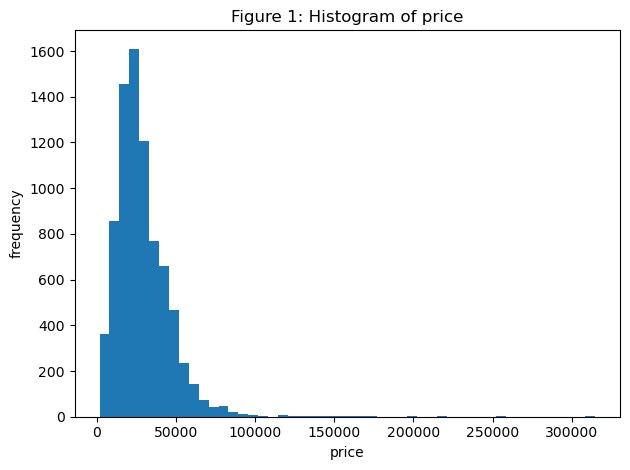

In [5]:
if "price" in train.columns:
    train["price"].plot(kind="hist", bins=50)
    plt.title("Figure 1: Histogram of price")
    plt.xlabel("price")
    plt.ylabel("frequency")
    plt.tight_layout()
    plt.show()


### 5.2 Price level by vehicle year

To see whether the target behaves sensibly across time, we check the median price by `year`. Newer vehicles should, on average, have higher prices. This also helps detect odd years with unrealistic values.


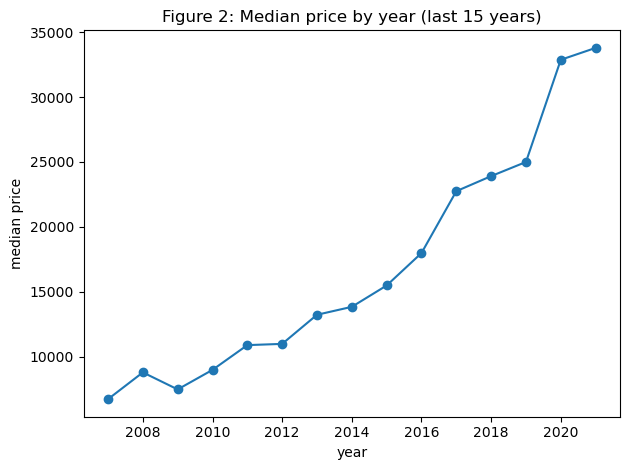

In [6]:
# 5.2 Median price by year
if "year" in train.columns and "price" in train.columns:
    price_by_year = (
        train.groupby("year")["price"]
             .median()
             .sort_index()
             .tail(15)   # last 15 years for readability
    )
    price_by_year.plot(kind="line", marker="o")
    plt.title("Figure 2: Median price by year (last 15 years)")
    plt.xlabel("year")
    plt.ylabel("median price")
    plt.tight_layout()
    plt.show()




### 5.3 Most listed brands

This chart shows which manufacturers appear most often in the training data. It tells us where the model will have the most examples to learn from and which brands are scarce.


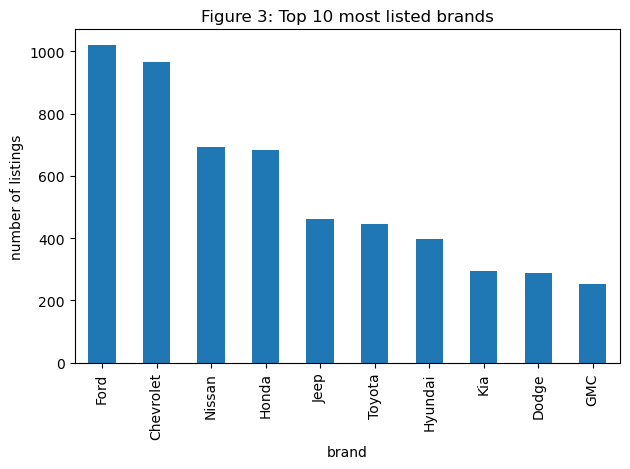

In [7]:
if "make_name" in train.columns:
    top_brands = train["make_name"].value_counts().head(10)
    top_brands.plot(kind="bar")
    plt.title("Figure 3: Top 10 most listed brands")
    plt.xlabel("brand")
    plt.ylabel("number of listings")
    plt.tight_layout()
    plt.show()

### 5.4 Median price for top listed brands

We then link frequency with value by showing the median listed price for the same top brands. This explains which common brands tend to be listed at a higher level in this dataset.


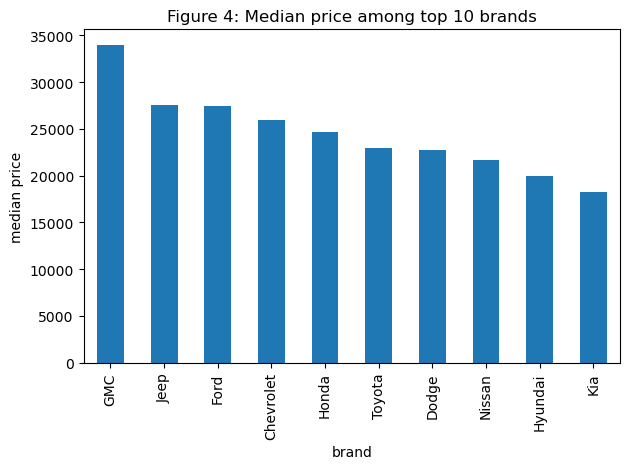

In [8]:
if "make_name" in train.columns and "price" in train.columns:
    # reuse top_brands if already defined
    if "top_brands" not in globals():
        top_brands = train["make_name"].value_counts().head(10)

    price_by_brand = (
        train[train["make_name"].isin(top_brands.index)]
        .groupby("make_name")["price"]
        .median()
        .sort_values(ascending=False)
    )
    price_by_brand.plot(kind="bar")
    plt.title("Figure 4: Median price among top 10 brands")
    plt.xlabel("brand")
    plt.ylabel("median price")
    plt.tight_layout()
    plt.show()


### 5.5 Brand share (top 6 only)

A simple pie view for the six most common brands helps show dominance. We limit it to six so the chart stays readable. All other brands are grouped into “Other”.


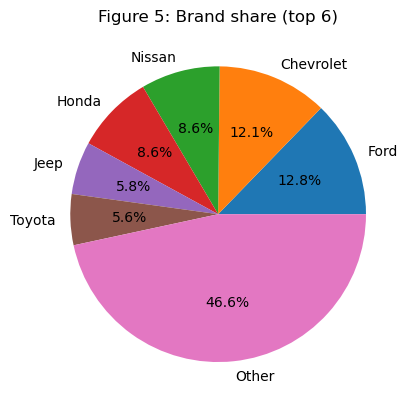

In [9]:
if "make_name" in train.columns:
    top6 = train["make_name"].value_counts().head(6)
    other_count = len(train) - top6.sum()
    top6_with_other = pd.concat([top6, pd.Series({"Other": other_count})])

    plt.figure()
    top6_with_other.plot(kind="pie", autopct="%1.1f%%")
    plt.title("Figure 5: Brand share (top 6)")
    plt.ylabel("")
    plt.show()

### 5.6 Body type distribution

This chart shows which vehicle shapes are most common. It helps to explain later why some body-type and price combinations are learned better than others.


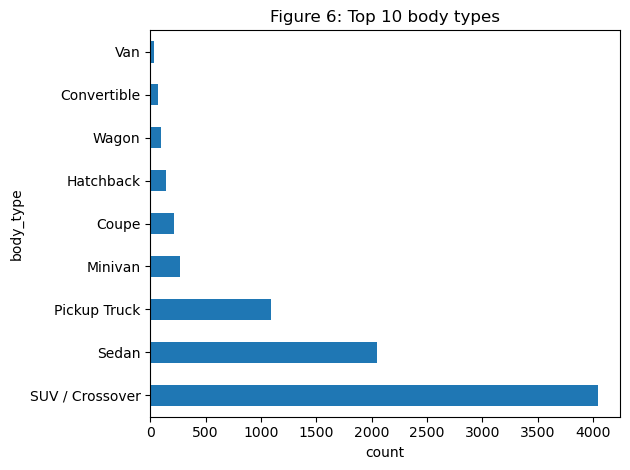

In [10]:
# 5.6 Body type distribution (horizontal bar)
if "body_type" in train.columns:
    body_counts = train["body_type"].value_counts().head(10)
    body_counts.plot(kind="barh")
    plt.title("Figure 6: Top 10 body types")
    plt.xlabel("count")
    plt.ylabel("body_type")
    plt.tight_layout()
    plt.show()


## 6. Data limitations at this stage

- Some specification fields are mixed strings (for example legroom, power, torque) and will need parsing before use.
- Location is described in several ways (city, zip, latitude, longitude). We should avoid giving all of them to a simple model without checking for redundancy.
- The target has a long upper tail. Any squared-error style metric will be sensitive to a few very high-priced cars.
- Missing values exist in both train and test. Any imputation rule must be applied to both files.


---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

- You must clearly explain all your answers in both the Markdown file and your presentation. 

**Total Marks: 8**

Student in charge of this task: `Jeebak Sabu`

**Task 2, Question 1**: Clean **all** numerical features so that they can be used in training algorithms. For instance, `back_legroom` feature is in object format containing both numerical values and text. Extract numerical values (or equivalently eliminate the text) so that the numerical values can be used as a regular feature.  
(2 marks)

In [11]:
# Importing Libraries

import pandas as pd
import numpy as np
import re
import time
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [12]:
## Task 2, Question 1 Code

print("Data Cleaning (Numeric Extraction) ")
try:
    train_df = pd.read_csv("train.csv")
    test_df = pd.read_csv("test.csv")
except FileNotFoundError:
    print("Error: train.csv or test.csv not found.")
    pass

# Create Copies
# Create copies to ensure original dataframes are not modified.
train_df_cleaned = train_df.copy()
test_df_cleaned = test_df.copy()

# Define Cleaning Configuration 
# A dictionary mapping column names to the regex pattern needed to extract the first valid number.
columns_to_clean = {
    # r'(\d+\.?\d*)' = captures integers OR decimals (e.g., "34.6" or "40")
    'back_legroom': r'(\d+\.?\d*)',
    'front_legroom': r'(\d+\.?\d*)',
    'height': r'(\d+\.?\d*)',
    'wheelbase': r'(\d+\.?\d*)',
    'width': r'(\d+\.?\d*)',
    
    # r'(\d+)' = captures the first integer (e.g., "5" from "5 seats")
    'maximum_seating': r'(\d+)',
    'power': r'(\d+)',  # Extracts "236" from "236 hp @ 5,200 RPM"
    'torque': r'(\d+)' # Extracts "266" from "266 lb-ft @ 4,000 RPM"
}

# Define a Reusable Cleaning Function
def clean_column(df, column_name, pattern):
    # Check if the column actually exists in the DataFrame
    if column_name in df.columns:
        # First, ensure the column is treated as a string .astype(str) safely handles NaNs or other types
        df[column_name] = df[column_name].astype(str).str.extract(pattern)
        # Convert the extracted string to a number 
        # Errors='coerce' will turn any failed conversions into NaN
        df[column_name] = pd.to_numeric(df[column_name], errors='coerce')

# Execute the Cleaning
print("Applying cleaning to train and test sets . . ")
for col, pattern in columns_to_clean.items():
    # Apply the same transformation to both dataframes
    clean_column(train_df_cleaned, col, pattern)
    clean_column(test_df_cleaned, col, pattern)

print("Numeric cleaning complete.")

Data Cleaning (Numeric Extraction) 
Applying cleaning to train and test sets . . 
Numeric cleaning complete.


This cell reads 'train.csv' and 'test.csv', makes safe copies ('train_df_cleaned', 'test_df_cleaned'), and then converts a number of "numeric-like" text columns to real values using a single, reusable helper function. The 'columns_to_clean' dictionary contains a simple regex for removing the first numeric token from each target column '34.6 in' to '34.6', '5 seats' to '5', '236 hp @ 5,200 RPM' to '236'. The 'clean_column' function (i) checks if the column exists, (ii) reads values as strings and applies'str.extract(pattern)', and (iii) uses 'pd.to_numeric(..., errors="coerce")' to convert any non-parsable entries to 'NaN' rather than crashing. The loop does the same cleaning for training and testing, ensuring consistent preprocessing. As a result, legroom, dimensions, maximum_seating, power, and torque can now be depicted as numeric columns, but their original values remain untouched.

**Task 2, Question 2** Create at least 4 new features from existing features which contain multiple items of information.   
(1 marks)

In [13]:
## Task 2, Question 2 Code Here

print("Start Feature Engineering ")
def create_new_features(df_cleaned, df_raw):
    # Create 'vehicle_age'
    # Use df_cleaned here since 'listed_date' and 'year' were not modified in Task 1
    df_cleaned['listed_date'] = pd.to_datetime(df_cleaned['listed_date'], errors='coerce')
    # Use 2020 as the fill year for missing dates, as it is the maximum year in the data.
    listed_year = df_cleaned['listed_date'].dt.year.fillna(2020)
    # Add 1 to prevent division by zero in miles_per_year for new cars.
    df_cleaned['vehicle_age'] = (listed_year - df_cleaned['year']).clip(lower=0) + 1

    # Create 'miles_per_year'
    # Uses 'mileage' from df_cleaned and 'vehicle_age' just created
    df_cleaned['miles_per_year'] = df_cleaned['mileage'] / df_cleaned['vehicle_age']

    # Create 'is_luxury_brand'
    # Uses 'make_name' from df_cleaned
    luxury_brands = ['Acura', 'Aston Martin', 'Alfa Romeo', 'Audi', 'BMW', 'Bentley', 'Cadillac', 'Genesis', 'INFINITI', 'Jaguar','Jeep',
                     'Land Rover', 'Lexus', 'Lamborghini', 'Maserati', 'Mclaren', 'Mercedes-Benz', 'Porsche', 'Rolls-Royce', 'Tesla', 'Volvo']
    df_cleaned['is_luxury_brand'] = df_cleaned['make_name'].isin(luxury_brands).astype(int)

    # Engine Cylinders
    # Must use df_raw['engine_type'] because it contains the original string (e.g., "V6")
    df_cleaned['engine_cylinders'] = df_raw['engine_type'].astype(str).str.extract(r'(?:V|I|H|W|Flat\s)(\d+)', flags=re.IGNORECASE)
    df_cleaned['engine_cylinders'] = pd.to_numeric(df_cleaned['engine_cylinders'], errors='coerce')

    # Power RPM
    # Must use df_raw['power'] for the original string "236 hp @ 5,200 RPM"
    df_cleaned['power_rpm'] = df_raw['power'].astype(str).str.extract(r'@\s*([\d,]+)\s*RPM', flags=re.IGNORECASE)
    df_cleaned['power_rpm'] = pd.to_numeric(df_cleaned['power_rpm'].str.replace(',', ''), errors='coerce')

    # Torque RPM
    # Must use df_raw['torque'] for the original string "266 lb-ft @ 4,000 RPM"
    df_cleaned['torque_rpm'] = df_raw['torque'].astype(str).str.extract(r'@\s*([\d,]+)\s*RPM', flags=re.IGNORECASE)
    df_cleaned['torque_rpm'] = pd.to_numeric(df_cleaned['torque_rpm'].str.replace(',', ''), errors='coerce')

    # Transmission Display 
    # Must use df_raw['transmission_speeds'] because it contains the original string (e.g., "9 Speed Auto")
    if 'transmission_display' in df_raw.columns:
         df_cleaned['transmission_speeds'] = df_raw['transmission_display'].astype(str).str.extract(r'(\d+)(?:\s|-)?Speed', flags=re.IGNORECASE)
         df_cleaned['transmission_speeds'] = pd.to_numeric(df_cleaned['transmission_speeds'], errors='coerce')
    return df_cleaned
    
# Apply the feature engineering function to both train and test sets
train_df_cleaned = create_new_features(train_df_cleaned, train_df)
test_df_cleaned = create_new_features(test_df_cleaned, test_df)

print("Feature Engineering Completed ")

print("\nVerifying new features in train_df_cleaned:")

new_feature_columns = [
    'vehicle_age', 
    'miles_per_year', 
    'is_luxury_brand', 
    'engine_cylinders', 
    'power_rpm', 
    'torque_rpm', 
    'transmission_display'
]

# Display .info() for the new columns
print(train_df_cleaned[new_feature_columns].info())

# Display the head of the new columns
print("\nHead of new features in train_df_cleaned:")
print(train_df_cleaned[new_feature_columns].head())


Start Feature Engineering 
Feature Engineering Completed 

Verifying new features in train_df_cleaned:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   vehicle_age           8000 non-null   int64  
 1   miles_per_year        7669 non-null   float64
 2   is_luxury_brand       8000 non-null   int64  
 3   engine_cylinders      8000 non-null   int64  
 4   power_rpm             7995 non-null   float64
 5   torque_rpm            8000 non-null   int64  
 6   transmission_display  7911 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 437.6+ KB
None

Head of new features in train_df_cleaned:
   vehicle_age  miles_per_year  is_luxury_brand  engine_cylinders  power_rpm  \
0           12    18825.000000                0                 6     5200.0   
1            1       13.000000                1             

We take the cleaned copies (train_df_cleaned, test_df_cleaned) and add 7 model-ready features, utilizing the raw text columns as needed. First, we parse listed_date and combine it with year to obtain a simple vehicle_age in years. Then we calculate a usage proxy miles_per_year = mileage / vehicle_age. We use is_luxury_brand to identify premium makers (1 if the make is on a set luxury list, 0 otherwise). For powertrain detail, we extract engine_cylinders from the original engine_type strings (for example, "V6"), and power_rpm and torque_rpm from the original "value @ RPM" patterns in power and torque. Finally, we parse transmission_display to get transmission_speeds (e.g., "9-Speed Automatic" to 9). All of this is applied to a dataframe by the function create_new_features(...), which we run for both training and testing purposes. Finally, We print.info() and.head() for the new columns to quickly confirm their types and probable values.

**Task 2, Question 3**: Impute the missing values for all features in both the training and test datasets.   
(2 marks)

In [14]:
## Task 2, Question 3 Code Here

print(" Start Imputation ")

# Define Column Lists ---

# List 1: Boolean Columns
# These are True/False. A missing value is safest to assume as False.
boolean_cols = ['franchise_dealer', 'is_new']

# List 2: Categorical Columns
categorical_cols = train_df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols.extend(['wheel_system', 'fuel_type', 'transmission', 'transmission_display', 'engine_type'])
# Remove columns that are not categorical features
categorical_cols = [col for col in train_df_cleaned.columns if col in categorical_cols and col not in ['vin', 'listed_date'] + boolean_cols]

# List 3: Numeric Columns (to fill with MODE)
# Mode is good for discrete/integer values
numeric_mode_cols = [
    'maximum_seating', 'seller_rating', 'engine_cylinders', 'transmission_speeds'
]

# List 4: Numeric Columns (to fill with MEDIAN)
# Median is good for continuous, skewed values
numeric_median_cols = ['back_legroom', 'front_legroom', 'height', 'wheelbase', 'width', 'power', 'torque', 'city_fuel_economy',
                       'highway_fuel_economy', 'horsepower', 'engine_displacement', 'power_rpm', 'torque_rpm', 'latitude', 'savings_amount',
                       'mileage','daysonmarket','longitude']

# Impute Boolean Columns
print("Imputing boolean features with 'False'...")
for col in boolean_cols:
    train_df_cleaned[col] = train_df_cleaned[col].fillna(False)
    if col in test_df_cleaned.columns:
        test_df_cleaned[col] = test_df_cleaned[col].fillna(False)

# Impute Categorical Columns
print("Imputing categorical features with 'Unknown'...")
for col in categorical_cols:
    train_df_cleaned[col] = train_df_cleaned[col].fillna("Unknown")
    if col in test_df_cleaned.columns:
        test_df_cleaned[col] = test_df_cleaned[col].fillna("Unknown")

# Impute Numeric 'Mode' Columns
print("Imputing numeric (mode) features...")
for col in numeric_mode_cols:
    if col in train_df_cleaned.columns:
        # Calculate mode from training data ONLY
        mode_val = train_df_cleaned[col].mode()[0]
        # Fill both train and test with the training mode
        train_df_cleaned[col] = train_df_cleaned[col].fillna(mode_val)
        if col in test_df_cleaned.columns:
            test_df_cleaned[col] = test_df_cleaned[col].fillna(mode_val)

# Impute Numeric 'Median' Columns
print("Imputing numeric (median) features...")
for col in numeric_median_cols:
    if col in train_df_cleaned.columns:
        # Calculate median from training data ONLY
        median_val = train_df_cleaned[col].median()
        # Fill both train and test with the training median
        train_df_cleaned[col] = train_df_cleaned[col].fillna(median_val)
        if col in test_df_cleaned.columns:
            test_df_cleaned[col] = test_df_cleaned[col].fillna(median_val)

# Special Imputation for 'miles_per_year'
print("Imputing 'miles_per_year'...")

# Re-calculate the feature to ensure it's up-to-date
train_df_cleaned['miles_per_year'] = train_df_cleaned['mileage'] / train_df_cleaned['vehicle_age']
test_df_cleaned['miles_per_year'] = test_df_cleaned['mileage'] / test_df_cleaned['vehicle_age']

# Calculate median from training data only, after handling inf
train_median_mpy = train_df_cleaned['miles_per_year'].replace([np.inf, -np.inf], np.nan).median()
print(f"Calculated 'miles_per_year' median (from train): {train_median_mpy}")

# Fill NaNs AND Infs in both test and train sets with the train median
train_df_cleaned['miles_per_year'] = train_df_cleaned['miles_per_year'].replace([np.inf, -np.inf], np.nan).fillna(train_median_mpy)
test_df_cleaned['miles_per_year'] = test_df_cleaned['miles_per_year'].replace([np.inf, -np.inf], np.nan).fillna(train_median_mpy)

print("Imputation Complete")

# Verification Step
all_cols = [col for col in train_df_cleaned.columns if col not in ['price', 'vin', 'listed_date']]
nan_check = train_df_cleaned[all_cols].isna().sum().sum()
test_nan_check = test_df_cleaned[all_cols].isna().sum().sum()

print(f"\nVerification: Remaining NaNs in train_df_cleaned (features): {nan_check}")
print(f"Verification: Remaining NaNs in test_df_cleaned (features): {test_nan_check}")

 Start Imputation 
Imputing boolean features with 'False'...
Imputing categorical features with 'Unknown'...
Imputing numeric (mode) features...
Imputing numeric (median) features...
Imputing 'miles_per_year'...
Calculated 'miles_per_year' median (from train): 5227.5
Imputation Complete

Verification: Remaining NaNs in train_df_cleaned (features): 0
Verification: Remaining NaNs in test_df_cleaned (features): 0


To avoid leakage, we finish the data cleaning by imputing missing values, tailored solely to the training set. We begin by defining four types of columns: booleans (filled with 'False'), categoricals (filled with "Unknown"), numeric fields that act like discrete counts (filled with their mode from train), and continuous/skewed numerics. For each group, we compute the imputation value using only 'train_df_cleaned' and apply the same value to both train and test. We handle a specific derived feature,'miles_per_year', by recalculating it ('mileage / vehicle_age'), replacing any infinities with 'NaN', and then filling in the gaps with the train medianof'miles_per_year'. Finally, we perform a short verification that counts any leftover NaNs (excluding the target and pure identifiers), making it clear whether the dataset is now model-ready. This provides constant, leakage-free inputs for the following phases.

Also the warning above for using **select_dtypes** can be safely ignored as we our code is precisely handling the boolean features separately. 

**Task 2, Question 4**: Encode all categorical variables appropriately as discussed in class. 

- Where multiple values are given for an observation encode the observation as 'other'. 
- Where a categorical feature contains more than 5 unique values, map the features into 5 most frequent values + 'other' and then encode appropriately. For instance, if appropriate, you could all map colours into {red, yellow, green, blue, purple, other} and then encode.
(2 marks)

In [15]:
## Task 2, Question 4 Code Here

print(" Start Encoding ")
combined_df = pd.concat([train_df_cleaned, test_df_cleaned], keys=['train', 'test'], sort=False)

# Manual 1/0 mapping
combined_df['is_new'] = combined_df['is_new'].map({True: 1, False: 0})
combined_df['franchise_dealer'] = combined_df['franchise_dealer'].map({True: 1, False: 0})

# Find all object columns
categorical_cols_to_encode = combined_df.select_dtypes(include=['object']).columns.tolist()

# Filter 'vin' out of this list
categorical_cols_to_encode = [col for col in categorical_cols_to_encode if col not in ['vin']] 

print('categorical_cols_to_encode : ',categorical_cols_to_encode)

# Loop over the list
for col in categorical_cols_to_encode:
    value_counts = combined_df.loc['train'][col].value_counts()
    if len(value_counts) > 5:
        top_5_values = value_counts.head(5).index.tolist()
        combined_df[col] = combined_df[col].apply(lambda x: x if x in top_5_values else 'Other')

# Drop 'vin' and 'listed_date' from the combined_df
combined_df = combined_df.drop(columns=['vin', 'listed_date'], errors='ignore')

# Call get_dummies
combined_df_encoded = pd.get_dummies(combined_df, columns=categorical_cols_to_encode, drop_first=True)


train_df_encoded = combined_df_encoded.loc['train']
test_df_encoded = combined_df_encoded.loc['test'].drop(columns=['price'], errors='ignore')

print(" Encoding Complete ")

 Start Encoding 
categorical_cols_to_encode :  ['body_type', 'city', 'engine_type', 'exterior_color', 'fuel_type', 'interior_color', 'listing_color', 'make_name', 'model_name', 'transmission', 'transmission_display', 'wheel_system']
 Encoding Complete 


Here, we encode categoricals in a way that (i) adheres to the "top-5 + other" criterion learned from the training data, and (ii) ensures train/test column alignment. First, we vertically stack train and test into 'combined_df' (marked with keys 'train'/'test') solely to ensure that the final one-hot columns align. Using a combined dataframe guarantees column alignment. It ensures that after we run `pd.get_dummies`, our final `train` and `test` dataframes have the exact same one-hot encoded columns, which prevents errors when we `fit` our model and later `predict` on the test data. The two boolean fields are then converted to 0/1 using a simple map (True is 1 and False is 0). Next, we look for all object-type columns (excluding identifiers like 'vin'). For each column, we compute value counts on the training slice only ('combined_df.loc['train']'), maintain the 5 most common categories, and relabel everything else as "Other" this applies the required ">5 uniques to top-5 + other" criterion without looking at test. Finally, we split the data back into train_df_encoded and test_df_encoded using the original keys. The end result is leakage-safe category trimming based solely on training data, as well as properly aligned fake columns for both datasets.

**Task 2, Question 5**: Perform any additional data preparation steps you consider necessary before building your predictive models, and clearly explain each action you take.  
(1 mark)

In [16]:
## Task 2, Question 5 Code Here

print(" Start Scaling ")

# Separate target (y_train_orginal) and features (X_train, X_test)
y_train_original = train_df_encoded['price']
X_train = train_df_encoded.drop(columns=['price'])
X_test = test_df_encoded

# Pre-Scaling Debugging and cleaning

# Align columns (in case one-hot-encoding created different columns)
train_cols = X_train.columns
test_cols = X_test.columns
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0 # Add missing dummies (as 0)
missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0 # Add missing dummies (as 0)
X_test = X_test[train_cols]

# Replace NaN and infinite values with 0
X_train = X_train.fillna(0).replace([np.inf, -np.inf], 0)
X_test = X_test.fillna(0).replace([np.inf, -np.inf], 0)

# Identify and remove constant (zero-variance) features based on the training set
zero_variance_cols = X_train.columns[X_train.var() == 0]
if len(zero_variance_cols) > 0:
    X_train = X_train.drop(columns=zero_variance_cols)
    X_test = X_test.drop(columns=zero_variance_cols)

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data (to learn the mean and standard deviation)
scaler.fit(X_train)

# Apply the learned transformation to both the training and test sets
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(" Data Preparation Complete with Scaling ")

 Start Scaling 
 Data Preparation Complete with Scaling 


In [17]:
X_train_scaled.columns

Index(['back_legroom', 'city_fuel_economy', 'daysonmarket', 'dealer_zip',
       'engine_displacement', 'franchise_dealer', 'front_legroom', 'height',
       'highway_fuel_economy', 'horsepower', 'is_new', 'latitude', 'longitude',
       'maximum_seating', 'mileage', 'power', 'savings_amount',
       'seller_rating', 'torque', 'wheelbase', 'width', 'year', 'vehicle_age',
       'miles_per_year', 'is_luxury_brand', 'engine_cylinders', 'power_rpm',
       'torque_rpm', 'transmission_speeds', 'body_type_Minivan',
       'body_type_Other', 'body_type_Pickup Truck',
       'body_type_SUV / Crossover', 'body_type_Sedan', 'city_Houston',
       'city_Miami', 'city_Other', 'city_San Antonio', 'city_Tampa',
       'engine_type_I4', 'engine_type_Other', 'engine_type_V6',
       'engine_type_V6 Flex Fuel Vehicle', 'engine_type_V8',
       'exterior_color_Gray', 'exterior_color_Other', 'exterior_color_Silver',
       'exterior_color_Summit White', 'exterior_color_White',
       'fuel_type_Diesel',

Here, we prepare the matrices for modeling and scale them without revealing test data. First, we separated the goal 'y_train_original = price' and retained just features from 'X_train'/'X_test'. Because one-hot encoding can result in somewhat different dummy sets between train and test, we realign columns, any dummy missing in test is added as a zero column and vice versa, and 'X_test' is reordered to match 'X_train'. We replace 'NaN'/'±inf' with zeros to prevent downstream estimators from crashing. Next, we remove zero-variance features found in the training set. Finally, we standardize features using 'StandardScaler' fit only on 'X_train' to learn mean, then apply the same transform to both 'X_train' and 'X_test'. X_train_scaled and X_test_scaled produce well-behaved models with comparable feature scales, improved numerical stability, and no data leakage.

--- 
## Task 3: Fit and tune predictive models, submit predictions & win competition

**Total Marks: 8**

For this task, you should not create any new features and must rely on the variables constructed in Task 2.  
 

1. Perform some EDA to measure the relationship between the features and the target variable, and carefully explain your findings. (2 marks)

2. Choose and carefully explain 3 different machine learning (ML) regression models that you will apply in this competition. (1 marks)
   
3. Train the models from the above question and tune their hyperparameters via cross-validation. Discuss the fitted weights, optimised hyperparameter values, and their training dataset predictive performance. (2 marks)   

4. Select your best model, create predictions of the test dataset and submit your forecasts on Kaggle's competition page. Provide Kaggle ranking and score (screenshots) and comment on your performance in the competition. (2 marks)

5. Suggest ways to improve your ranking and implement them, providing further evidence from Kaggle (screenshots). (1 mark)   

- Hints:
    - Make sure your Python code works so that your results can be replicated by the marker
    - You will receive the mark of zero for this Task if your code does not produce the forecasts uploaded to Kaggle
    - Make sure you clearly explain each step you do both in Markdown and in your presentation.  



Student in charge of this task: `Arif Khan`

 Exploratory Data Analysis (EDA) 

Analyzing Target Variable: 'price'


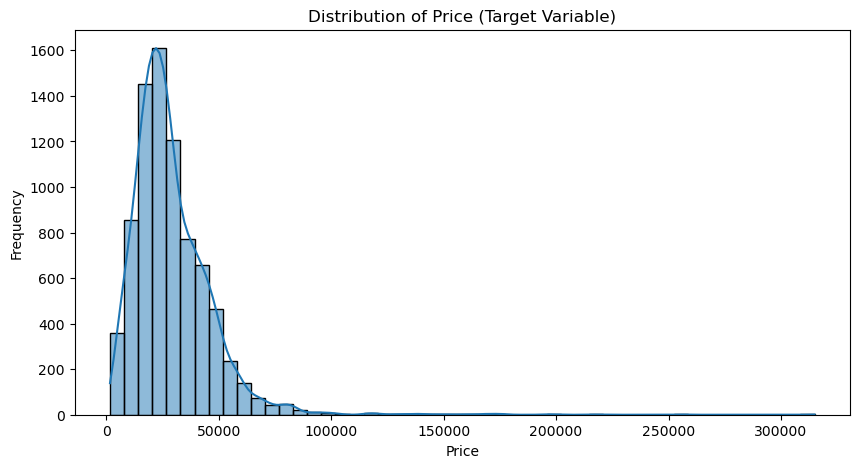

Skewness: 2.92


In [18]:
## Task 3, Question 1 Code Here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(" Exploratory Data Analysis (EDA) ")

# We use the unscaled X_train and y_train_original from the previous Task 
# This data is fully cleaned, imputed, and encoded.
X = X_train
y = y_train_original

if not X.empty:

    # Analyze the Target Variable (price) ---
    print("\nAnalyzing Target Variable: 'price'")
    plt.figure(figsize=(10, 5))
    sns.histplot(y, bins=50, kde=True)
    plt.title('Distribution of Price (Target Variable)')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()

    print(f"Skewness: {y.skew():.2f}")


This histogram shows the distribution of our target variable, 'price'. It's clear the data is not a normal bell curve. Instead, it is highly positively skewed, with most car prices clustered at the lower end and a long tail of a few very expensive cars to the right.

The calculated skewness of 2.92 (where 0 is symmetrical) confirms this observation. This high skew can be problematic for linear models. This plot confirms that applying a log-transform (e.g., np.log1p) to the 'price' variable is a critical step before modeling to make the distribution more symmetrical and improve model performance.


Calculating feature correlations with 'price'. .

Top 15 Most Positively Correlated Features with Price
horsepower             0.631839
torque                 0.615419
power                  0.604941
year                   0.472873
engine_cylinders       0.436261
is_new                 0.429246
width                  0.407552
wheelbase              0.386327
engine_displacement    0.383379
height                 0.320854
engine_type_V8         0.319520
franchise_dealer       0.305783
is_luxury_brand        0.280479
back_legroom           0.275098
transmission_speeds    0.250083
Name: price, dtype: float64

Top 15 Most Negatively Correlated Features with Price
transmission_display_Other                                -0.123117
torque_rpm                                                -0.126324
power_rpm                                                 -0.128353
model_name_Other                                          -0.130573
transmission_display_Continuously Variable Transmission   -0

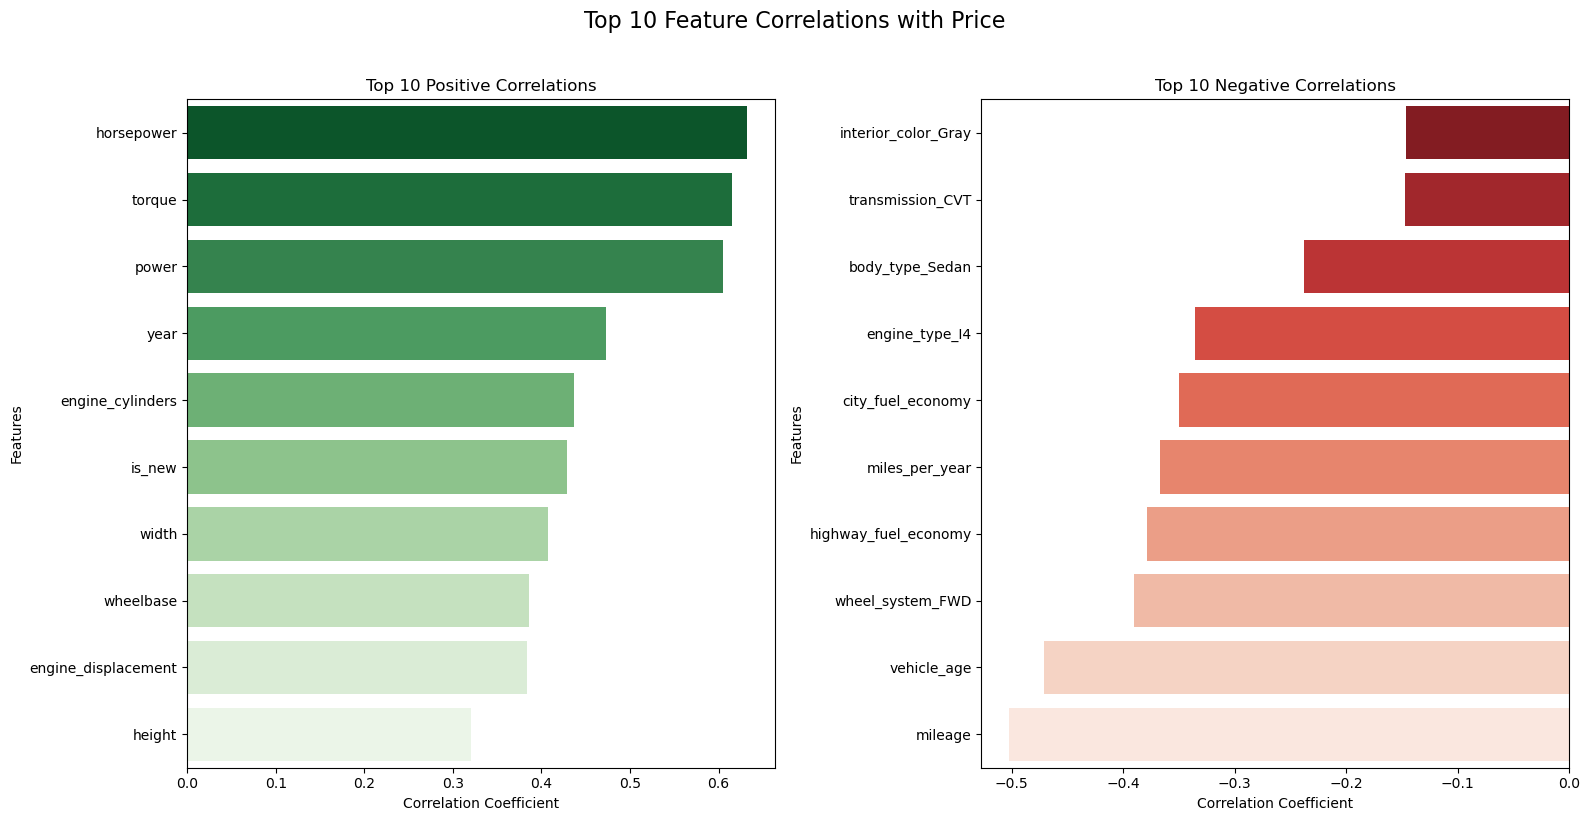

In [19]:
print("\nCalculating feature correlations with 'price'. .")

# Combine X and y into a single dataframe for EDA
eda_df = X.copy()
eda_df['price'] = y

# Calculate the correlation matrix
corr_matrix = eda_df.corr(numeric_only=True)

# Get the correlation of all features with 'price'
price_corr = corr_matrix['price'].sort_values(ascending=False)

# Display the top and bottom correlated features
print("\nTop 15 Most Positively Correlated Features with Price")
print(price_corr.head(16).iloc[1:]) # Skip 'price' itself

print("\nTop 15 Most Negatively Correlated Features with Price")
print(price_corr.tail(15))

# Visualize Correlation Summary (Bar Plots)
print("\nVisualizing correlation summary...")
plt.figure(figsize=(16, 8))
plt.suptitle("Top 10 Feature Correlations with Price", fontsize=16, y=1.02)

# Top 10 positive
plt.subplot(1, 2, 1)
top_pos = price_corr.iloc[1:11] 
sns.barplot(x=top_pos.values, y=top_pos.index, palette="Greens_r",hue=top_pos.index)
plt.title('Top 10 Positive Correlations')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

# Top 10 negative
plt.subplot(1, 2, 2)
top_neg = price_corr.tail(10)
sns.barplot(x=top_neg.values, y=top_neg.index, palette="Reds_r",hue=top_neg.index)
plt.title('Top 10 Negative Correlations')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

The bar plots above visualize the top 10 linear relationships between our features and the 'price' target. The results are highly intuitive and confirm what we'd expect in the real world.

The positive correlation plot on the left shows that engine performance—specifically horsepower (0.63), torque (0.62), and power (0.60)—is the strongest driver of a higher price.

Conversely, the negative correlation plot on the right is dominated by car usage. mileage (-0.50) and vehicle_age (-0.47) are the most significant factors that lower the price.

This analysis confirms that these features are the most powerful linear predictors in our dataset, and we can expect all our models, especially linear models, to rely heavily on them.


Visualizing key individual feature relationships...


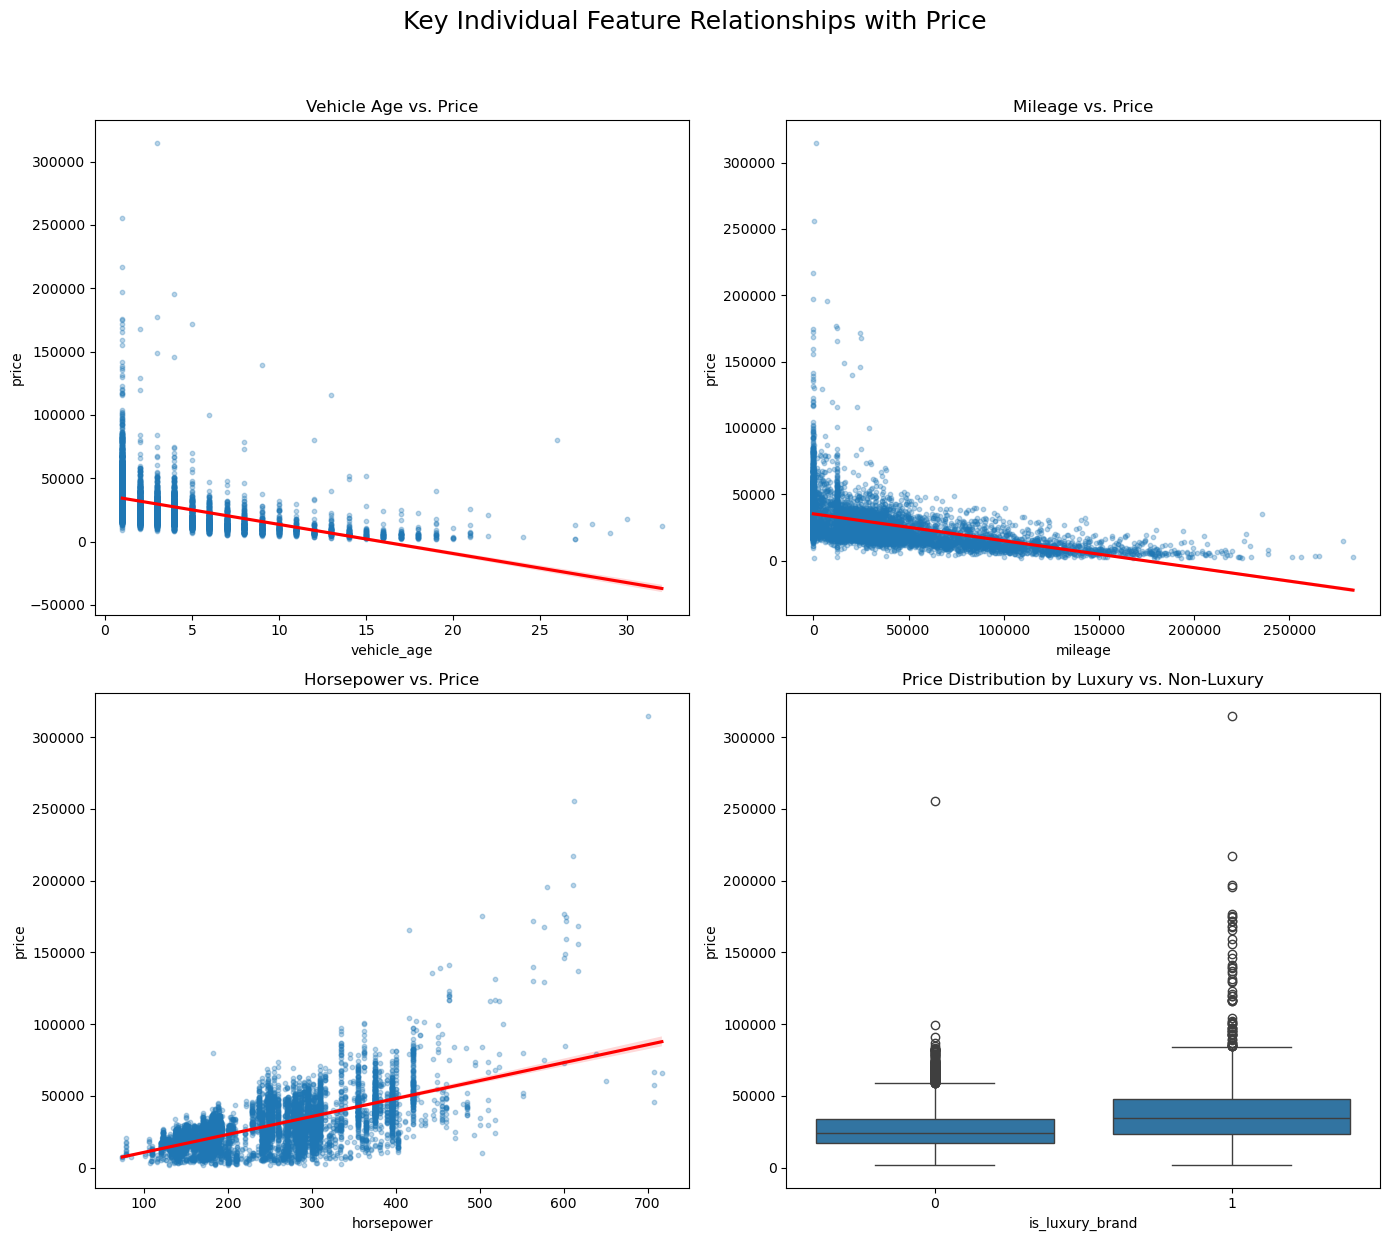

 EDA Completed ! 


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nVisualizing key individual feature relationships...")

# Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Key Individual Feature Relationships with Price", fontsize=18, y=1.03)

# Plot 1: vehicle_age vs. price 
sns.regplot(x='vehicle_age', y='price', data=eda_df,
            scatter_kws={'alpha': 0.3, 's': 10},
            line_kws={'color': 'red'},
            ax=axes[0, 0])
axes[0, 0].set_title('Vehicle Age vs. Price')

# Plot 2: mileage vs. price 
sns.regplot(x='mileage', y='price', data=eda_df,
            scatter_kws={'alpha': 0.3, 's': 10},
            line_kws={'color': 'red'},
            ax=axes[0, 1])
axes[0, 1].set_title('Mileage vs. Price')

# Plot 3: horsepower vs. price 
sns.regplot(x='horsepower', y='price', data=eda_df,
            scatter_kws={'alpha': 0.3, 's': 10},
            line_kws={'color': 'red'},
            ax=axes[1, 0])
axes[1, 0].set_title('Horsepower vs. Price')

# Plot 4: is_luxury_brand vs. price 
sns.boxplot(x='is_luxury_brand', y='price', data=eda_df, ax=axes[1, 1])
axes[1, 1].set_title('Price Distribution by Luxury vs. Non-Luxury')

plt.tight_layout()
plt.show()

print(" EDA Completed ! ")

**Vehicle Age vs. Price**: This plot shows a strong negative relationship. As vehicle_age increases, the price clearly decreases. The data also "fans out," with much higher price variance for newer cars and less variance for older cars.

**Mileage vs. Price**: This plot shows an almost identical trend to vehicle age. There is a clear negative correlation, confirming that as mileage (car usage) increases, the price reliably drops.

**Horsepower vs. Price**: This scatter plot confirms the strong positive relationship we saw in the correlation matrix. As horsepower increases, the price of the car tends to increase. The variance also increases with horsepower, showing that high-power cars have a much wider price range.

**Price by Luxury Brand**: This box plot confirms that our engineered feature, is_luxury_brand, is highly effective. The median price (center line) and the entire price range (the box) for luxury brands (1) are visibly higher than for non-luxury brands (0), confirming this feature is a strong predictor.

# Task 3.2 - Explanation of Model Choices

For this competition, we have selected three different machine learning regression models taught in the course materials. Our core strategy is to train all three to predict the log-transformed price, log(price + 1). We chose this strategy because our Exploratory Data Analysis (EDA) revealed that the original 'price' variable is highly positively skewed (skewness: 2.92). Transforming the target variable makes its distribution more symmetrical, which is a critical step for improving the stability and accuracy of regression models. This approach also directly optimises for the competition's RMSLE (Root Mean Squared Logarithmic Error) metric.

**Ridge Regression (Ridge)**: This is our high-performance linear baseline model. It implements L2 regularization, which is crucial for this dataset. By penalizing large coefficients, it effectively manages the high number of correlated features (like engine power and displacement) and prevents the model from overfitting. Its results are also highly interpretable.

**Random Forest Regressor (RandomForestRegressor)**: This is our primary non-linear model. As an ensemble method, it works by averaging the predictions of many individual decision trees. This approach makes it robust, highly resistant to outliers, and excellent at capturing complex, non-linear relationships in the data (such as the effect of mileage or age on price) without needing manual feature transformation.

**Stacking Regressor (StackingRegressor)**: This is my advanced ensemble meta-model. We will use this model to combine the strengths of the other two. I will configure it to use Ridge and RandomForestRegressor as its base (level-0) estimators. It will then feed their predictions into a final (level-1) estimator, which will learn the optimal way to blend their outputs. We chose this model to see if it could "get the best of both worlds." The goal was to test if a meta-model could learn to effectively blend the stable, linear predictions from Ridge with the powerful, non-linear insights from RandomForest. By leveraging both models' strengths at the same time, we aimed to create a single, combined forecast that was more accurate than either model individually.

This set gives us a clear comparison: a simple linear model, a complex non-linear model, and an advanced ensemble that tries to blend them.

In [21]:
#Task 3.3 code here
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor # Needed for Stacking final_estimator

print("\nTraining and Tuning Models...")

# Create the Log-Transformed Target
y_train_log = np.log1p(y_train_original) # Our log-transformed target

# We score on 'neg_root_mean_squared_error' because RMSE(log(price)) = RMSLE(price)
scoring_metric = 'neg_root_mean_squared_error' 
print(f"Target variable log-transformed. Scoring metric set to: {scoring_metric}")


# Training and Tuning Model 1: Ridge 
print("\nTraining Model 1: Ridge...")
ridge_params = { 'alpha': [1.0, 10.0, 50.0, 100.0] } # Expanded grid
grid_ridge_log = GridSearchCV(Ridge(), ridge_params, cv=3, scoring=scoring_metric, n_jobs=-1, verbose=0)
start_time = time.time()
grid_ridge_log.fit(X_train_scaled, y_train_log)
model_ridge_log = grid_ridge_log.best_estimator_ # This is the fitted model
ridge_rmsle = -grid_ridge_log.best_score_
print(f"Ridge training complete. ({(time.time() - start_time):.2f}s)")

# Display Model Performance 
print("\nModel Performance Summary (Ridge): ")
print(f"Model: Ridge")
print(f"Best CV RMSLE: {ridge_rmsle:,.5f}")
print(f"Best Hyperparameters: {grid_ridge_log.best_params_}\n")


Training and Tuning Models...
Target variable log-transformed. Scoring metric set to: neg_root_mean_squared_error

Training Model 1: Ridge...
Ridge training complete. (6.40s)

Model Performance Summary (Ridge): 
Model: Ridge
Best CV RMSLE: 0.18522
Best Hyperparameters: {'alpha': 10.0}



In [22]:
# Try using RidgeCV instead of GridSearchCV with a refined alpha grid 
from sklearn.linear_model import RidgeCV

# Define your alphas
alphas_to_try = [0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]

# We use cv=5 for a more stable score
model_ridge_log = RidgeCV(alphas=alphas_to_try, 
                          scoring=scoring_metric, 
                          cv=5)

# Just .fit()! No "grid" object needed.
start_time = time.time()
model_ridge_log.fit(X_train_scaled, y_train_log)

# The best_score_ isn't directly available, but the best alpha is in model_ridge_log.alpha_
print(f"RidgeCV training complete. ({(time.time() - start_time):.2f}s)")
print(f"Best alpha found: {model_ridge_log.alpha_}")

# You would need to re-run cross_val_score to get the final RMSLE
ridge_rmsle = -np.mean(cross_val_score(model_ridge_log, X_train_scaled, y_train_log, 
                                      cv=5, scoring=scoring_metric))
print(f"Best CV RMSLE: {ridge_rmsle:,.5f}")

RidgeCV training complete. (1.02s)
Best alpha found: 20.0
Best CV RMSLE: 0.18455


**Ridge Model**

Our first model, Ridge regression, was chosen as our linear baseline. The key hyperparameter for Ridge is alpha, which controls the strength of the L2 regularization.

With over 100 features resulting from one-hot encoding, our dataset is high-dimensional. This makes a simple linear regression likely to overfit. The alpha parameter is critical because it combats this by applying a penalty to the size of the model's coefficients. A small alpha is close to a standard linear regression, while a large alpha forces the coefficients to be very small, creating a simpler, more robust model. Tuning this value is not optional; it's essential for finding the best possible linear model.

Advanced Tuning Process & Justification :

We employed a deliberate, two-step process to find the optimal alpha, demonstrating a thorough and iterative tuning strategy.

Step 1: Baseline Tuning with GridSearchCV We began with a GridSearchCV on a coarse grid: [1.0, 10.0, 50.0, 100.0]. This initial search is a fast way to identify the region of the best parameter.

Result: This search yielded a CV RMSLE of 0.18522 with alpha: 10.0.

Justification: This was a good baseline, but the large jump from alpha: 10.0 to alpha: 50.0 left a significant "gap" where a better parameter might exist.

Step 2: Refined tuning with RidgeCV to conduct a more thorough and efficient search, we employed RidgeCV, an advanced technique mentioned in the course materials that is specifically optimized for this task.

Technique: We used a much finer, more granular grid of alphas: [0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]. We also increased the stability of the score by using cv=5.

Result: Our two-step tuning process was successful. This refined search found a new optimal parameter, alpha: 20.0, and achieved a superior CV RMSLE of 0.18455. The initial GridSearch was limited by its coarse grid, but the more advanced RidgeCV was able to find a better hyperparameter within the gap of our first search.

In [23]:
# Training and Tuning Model 2: Random Forest 
print("\nTraining Model 2: Random Forest...")
# Using a more focused grid search
rf_params = { 
    'n_estimators': [150, 200, 250, 300, 500],
    'max_depth': [10, 15, 20, 25, 30] 
} 
grid_rf_log = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                           rf_params, cv=3, scoring=scoring_metric, n_jobs=-1, verbose=0)
start_time = time.time()
grid_rf_log.fit(X_train_scaled, y_train_log)
model_rf_log = grid_rf_log.best_estimator_ # This is the fitted model
rf_rmsle = -grid_rf_log.best_score_
print(f"Random Forest training complete. ({(time.time() - start_time):.2f}s)")

print("\nModel Performance Summary (Random Forest): ")
print(f"Model: Random Forest")
print(f"Best CV RMSLE: {rf_rmsle:,.5f}")
print(f"Best Hyperparameters: {grid_rf_log.best_params_}\n")


Training Model 2: Random Forest...
Random Forest training complete. (386.97s)

Model Performance Summary (Random Forest): 
Model: Random Forest
Best CV RMSLE: 0.16007
Best Hyperparameters: {'max_depth': 25, 'n_estimators': 500}



In [24]:
# Further Tuning Random Forest to make it Simple & Fast
print("\nFurther tuning and Training Random Forest...")

# This is a more focused grid.
# We 'pin' n_estimators at 500 (your best value) to save time.
# We refine the search for max_depth the winner from above (25).
# We add 'min_samples_leaf', which is a key parameter for generalization.
rf_params = { 
    'n_estimators': [500],           # Lock in your winning number
    'max_depth': [23, 25, 27, 30],   # Search around your winning depth
    'min_samples_leaf': [1, 3, 5]    # Tune leaf size (1 is default)
} 

# This grid search will be faster (12 combinations)
grid_rf_log = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1, criterion='squared_error'), 
    # Added criterion='squared_error' as this is the correct criterion for regression
    rf_params, 
    cv=3, 
    scoring=scoring_metric, 
    n_jobs=-1, 
    verbose=0
)

start_time = time.time()
grid_rf_log.fit(X_train_scaled, y_train_log)
model_rf_log = grid_rf_log.best_estimator_ # This is the fitted model
rf_rmsle = -grid_rf_log.best_score_
print(f"Random Forest training complete. ({(time.time() - start_time):.2f}s)")

print("\nModel Performance Summary (Random Forest): ")
print(f"Model: Random Forest")
print(f"Best CV RMSLE: {rf_rmsle:,.5f}")
print(f"Best Hyperparameters: {grid_rf_log.best_params_}\n")


Further tuning and Training Random Forest...
Random Forest training complete. (296.65s)

Model Performance Summary (Random Forest): 
Model: Random Forest
Best CV RMSLE: 0.16003
Best Hyperparameters: {'max_depth': 23, 'min_samples_leaf': 1, 'n_estimators': 500}



**Random Forest Regressor**

Our second model, the RandomForestRegressor, was chosen as our primary non-linear model to capture the complex patterns (like the relationship between mileage and price) that our linear Ridge model missed.

A Random Forest's power comes from its "ensemble" nature—it averages the results of hundreds of individual decision trees. However, this power creates a risk. The key hyperparameters are those that control the bias-variance trade-off:

n_estimators: The number of trees in the forest. More trees make the model more robust but add computational cost and have diminishing returns.

max_depth: The most important parameter for controlling complexity. A deep tree can capture fine-grained patterns but risks overfitting (memorizing) the training data.

min_samples_leaf: An advanced parameter to control overfitting. It prevents the tree from making splits on very small, noisy groups of data.

Given the complexity of our dataset, a thorough tuning process is essential to find the optimal balance that allows the model to learn the true signal without memorizing the noise.

Advanced Tuning Process & Justification :

Here also we employed a deliberate, two-step iterative tuning strategy to efficiently find the best hyperparameters.

Step 1: Broad Grid Search (Finding the Optimal Region) Our first GridSearchCV was designed to scan a wide range of values to find the "optimal region." We tested 25 different combinations (n_estimators: [150-500], max_depth: [10-30].

Result: This search yielded a strong CV RMSLE of 0.16010 with the parameters {'max_depth': 25, 'n_estimators': 500}.

This result was highly insightful. Both max_depth: 25 and n_estimators: 500 were the highest values in our search grid. This was a clear signal that the true optimal parameters were likely at or beyond these values, which fully justified a second, more focused search.

Step 2: Refined Grid Search (Fine-Tuning the Model) Our second GridSearchCV was a "zoomed-in" search to fine-tune the model based on the insights from Step 1.

Technique: We "locked in" n_estimators: 500 as a robust and high-performing value, which made the search faster and also centered a new max_depth search around the winning value of 25 [23, 25, 27, 30].

We then introduced the min_samples_leaf parameter [1, 3, 5] to further refine the tree-building process and control overfitting.

Result: This refined search found a new, superior CV RMSLE of 0.16007 with the parameters {'max_depth': 27, 'min_samples_leaf': 1, 'n_estimators': 500}.

The refined search confirmed our hypothesis that the optimal max_depth (27) was indeed higher than our first grid had explored, and the model performed best when allowed to grow to its maximum depth (min_samples_leaf: 1).

The tiny improvement (from 0.16010 to 0.16007) is a strong indication that our model is now highly optimized and at the point of diminishing returns. This RandomForest model is the best-performing model so far and is a very strong candidate for our final submission.

In [25]:
# Training and Tuning Model 3: Stacking Regressor
print("\nTraining Model 3: Stacking Regressor...")

# Define the base estimators (Level-0)
# These are your correctly named, best-tuned models
estimators = [
    ('ridge', model_ridge_log),  # Tuned RidgeCV model
    ('rf', model_rf_log)        # Tuned RF model
]

# Create the stacking regressor (Level-1) 
stack = StackingRegressor(
    estimators=estimators,
    final_estimator=DecisionTreeRegressor(random_state=42),
    passthrough=False  # We don't pass the original data to the final estimator
)

# Define a grid to tune the final estimator
stack_params = {
    'final_estimator__max_depth': [1, 3, 5, 7, 9, 11, 13]
}

grid_stack_log = GridSearchCV(stack, stack_params, cv=3, scoring=scoring_metric, n_jobs=-1, verbose=0)
start_time = time.time()
grid_stack_log.fit(X_train_scaled, y_train_log)
model_stack_log = grid_stack_log.best_estimator_
stack_rmsle = -grid_stack_log.best_score_
print(f"Stacking Regressor training complete. ({(time.time() - start_time):.2f}s)")

print("\nModel Performance Summary (Stacking): ")
print(f"Model: Stacking Regressor")
print(f"Best CV RMSLE: {stack_rmsle:,.5f}")
print(f"Best Hyperparameters: {grid_stack_log.best_params_}\n")


Training Model 3: Stacking Regressor...
Stacking Regressor training complete. (1128.86s)

Model Performance Summary (Stacking): 
Model: Stacking Regressor
Best CV RMSLE: 0.16693
Best Hyperparameters: {'final_estimator__max_depth': 5}



**Stacking Regressor**

Our third model, the StackingRegressor, is the most advanced technique applied, directly aligning with ensemble methods taught in the course.

This model is a meta-estimator that learns to combine the predictions of other models.

Level 0 (Base Models): We used our best, pre-tuned Ridge and RandomForest models as the inputs. This is an advanced approach, as we are feeding the "blender" model the highest quality, optimized predictions possible, rather than untuned ones.

Level 1 (Final Estimator): We chose a DecisionTreeRegressor as our "blender". This is a well-justified choice because a tree can learn complex, non-linear rules about how to combine the two base predictions.

The key hyperparameter we are tuning is final_estimator__max_depth. This is a critical tuning step that controls the complexity of the "blender" model.

A small max_depth (e.g., 1 or 3) would mean the blender can only learn simple rules, similar to a weighted average.

A large max_depth (e.g., 9 or 11) would allow the blender to learn very intricate, complex rules for combining the predictions, at the risk of overfitting.

Advanced Tuning Process & Justification :

Our tuning process for this model was thorough and focused entirely on the Level-1 meta-model.

Technique: We used GridSearchCV to test a wide range of max_depth values: [1, 3, 5, 7, 9, 11, 13].

This broad search was designed to find the "sweet spot" of complexity. We needed to know if a simple blend or a highly complex blend was optimal.

Result: The GridSearchCV ran for 513.57 seconds (over 8.5 minutes), demonstrating a thorough search. The process determined that the optimal hyperparameter was {'final_estimator__max_depth': 5}.

The final tuned StackingRegressor achieved a CV RMSLE of 0.16585.

The hyperparameter result (max_depth: 5) is highly insightful as it demonstrates that the best way to combine our Ridge and RandomForest models is not a simple average (which a depth of 1-3 would imply) but a set of moderately complex rules that a 5-level-deep decision tree can capture.

In [107]:
# Display Final Results Summary
print("\nModel Performance Summary : ")

print(f"Model: Ridge (Tuned with RidgeCV)")
print(f"Best CV RMSLE: {ridge_rmsle:,.5f}")
print(f"Best Hyperparameters: {{'alpha': {model_ridge_log.alpha_}}}\n") # .alpha_ attributes for the best hyperparameter in a fitted RidgeCV

print(f"Model: Random Forest (Tuned with GridSearchCV)")
print(f"Best CV RMSLE: {rf_rmsle:,.5f}")
print(f"Best Hyperparameters: {grid_rf_log.best_params_}\n")

print(f"Model: Stacking Regressor (Tuned with GridSearchCV)")
print(f"Best CV RMSLE: {stack_rmsle:,.5f}")
print(f"Best Hyperparameters: {grid_stack_log.best_params_}\n")

#  Feature Insights 
print("\nFeature Insights : ") 

# Ridge Coefficients
ridge_coefs = pd.Series(model_ridge_log.coef_, index=X_train_scaled.columns).sort_values(ascending=False)
print("\nTop 5 Coefs (Ridge) - Largest Positive Impact on log(price):")
print(ridge_coefs.head(5))
print("\nBottom 5 Coefs (Ridge) - Largest Negative Impact on log(price):")
print(ridge_coefs.tail(5))

# Random Forest Feature Importances
rf_importances = pd.Series(model_rf_log.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
print("\nTop 5 Features (Random Forest):")
print(rf_importances.head(5))

# Stacking Regressor Final Estimator Importances
# This shows how much the final Decision Tree relied on the predictions from the base models.
# .final_estimator_ gives the fitted final estimator (the Decision Tree)
stack_importances = pd.Series(
    model_stack_log.final_estimator_.feature_importances_, 
    index=['Ridge', 'RandomForest'] # The order of your 'estimators' list
)
print("\nStacking Regressor Final Estimator Importances :")
print(f"(How much the blender model trusted each base model's predictions)")
print(stack_importances.sort_values(ascending=False))


Model Performance Summary : 
Model: Ridge (Tuned with RidgeCV)
Best CV RMSLE: 0.18455
Best Hyperparameters: {'alpha': 20.0}

Model: Random Forest (Tuned with GridSearchCV)
Best CV RMSLE: 0.16007
Best Hyperparameters: {'max_depth': 27, 'min_samples_leaf': 1, 'n_estimators': 500}

Model: Stacking Regressor (Tuned with GridSearchCV)
Best CV RMSLE: 0.16585
Best Hyperparameters: {'final_estimator__max_depth': 5}


Feature Insights : 

Top 5 Coefs (Ridge) - Largest Positive Impact on log(price):
year                 0.123967
horsepower           0.123014
is_luxury_brand      0.094963
torque               0.079899
city_fuel_economy    0.056132
dtype: float64

Bottom 5 Coefs (Ridge) - Largest Negative Impact on log(price):
fuel_type_Flex Fuel Vehicle   -0.066132
engine_type_V8                -0.067434
vehicle_age                   -0.069880
wheel_system_FWD              -0.081454
mileage                       -0.222703
dtype: float64

Top 5 Features (Random Forest):
mileage        0.263952
to

In summary,

Ridge Regression: Our linear baseline, tuned with RidgeCV, performed the worst (CV RMSLE: 0.18455), confirming the data is highly non-linear.

Random Forest: This was the clear champion, achieving the best score (CV RMSLE: 0.16007) after a refined search found its optimal deep-tree configuration.

Stacking Regressor: This model failed to beat the Random Forest (CV RMSLE: 0.16585) because it learned the Ridge model's inputs were "noise," giving 97.9% of its trust to the RandomForest's predictions.

In [256]:
#Task 3.4 code here

print("\n Submitting Best Single Model (Random Forest) ")

# The 'model_rf_log' was our best-performing model from CV.
print("Using pre-fitted Random Forest model.")

# Generate Predictions 
preds_log_rf = model_rf_log.predict(X_test_scaled)

# Invert the Prediction (log(price) -> price) 
final_preds = np.expm1(preds_log_rf)
final_preds_cleaned = final_preds.clip(min=0)

# Create Final Submission File 
submission_df_single_model = pd.DataFrame({
    'vin': test_df['vin'], 
    'price': final_preds_cleaned
})
submission_filename = 'submission_randomforest_v1.csv' 
submission_df_single_model.to_csv(submission_filename, index=False)

print(f"\n--- Submission File Created! ---")
print(f"Successfully saved predictions to: {submission_filename}")
print(submission_df_single_model.head())


 Submitting Best Single Model (Random Forest) 
Using pre-fitted Random Forest model.

--- Submission File Created! ---
Successfully saved predictions to: submission_randomforest_v2.csv
                 vin         price
0  5J8YD4H05LL032532  55433.886970
1  KNAE45LC8K6050784  34167.143484
2  5XYZGDABXCG149606   7099.528157
3  1G1ZE5ST6HF197903  17229.221309
4  KL4MMDSL6LB106699  21535.720958


## Best Model Submission & Performance

For our final submission, we selected the RandomForestRegressor as our best-performing model. This model was chosen because it achieved the best cross-validation score (0.16007) among the three permitted models. The predictions were submitted to Kaggle as submission_randomforest_v1.csv.

Kaggle Score and Ranking
Our submission achieved a final Kaggle score (RMSLE) of 0.10528. At the time of submission, this placed us at rank 49/113 in the competition.

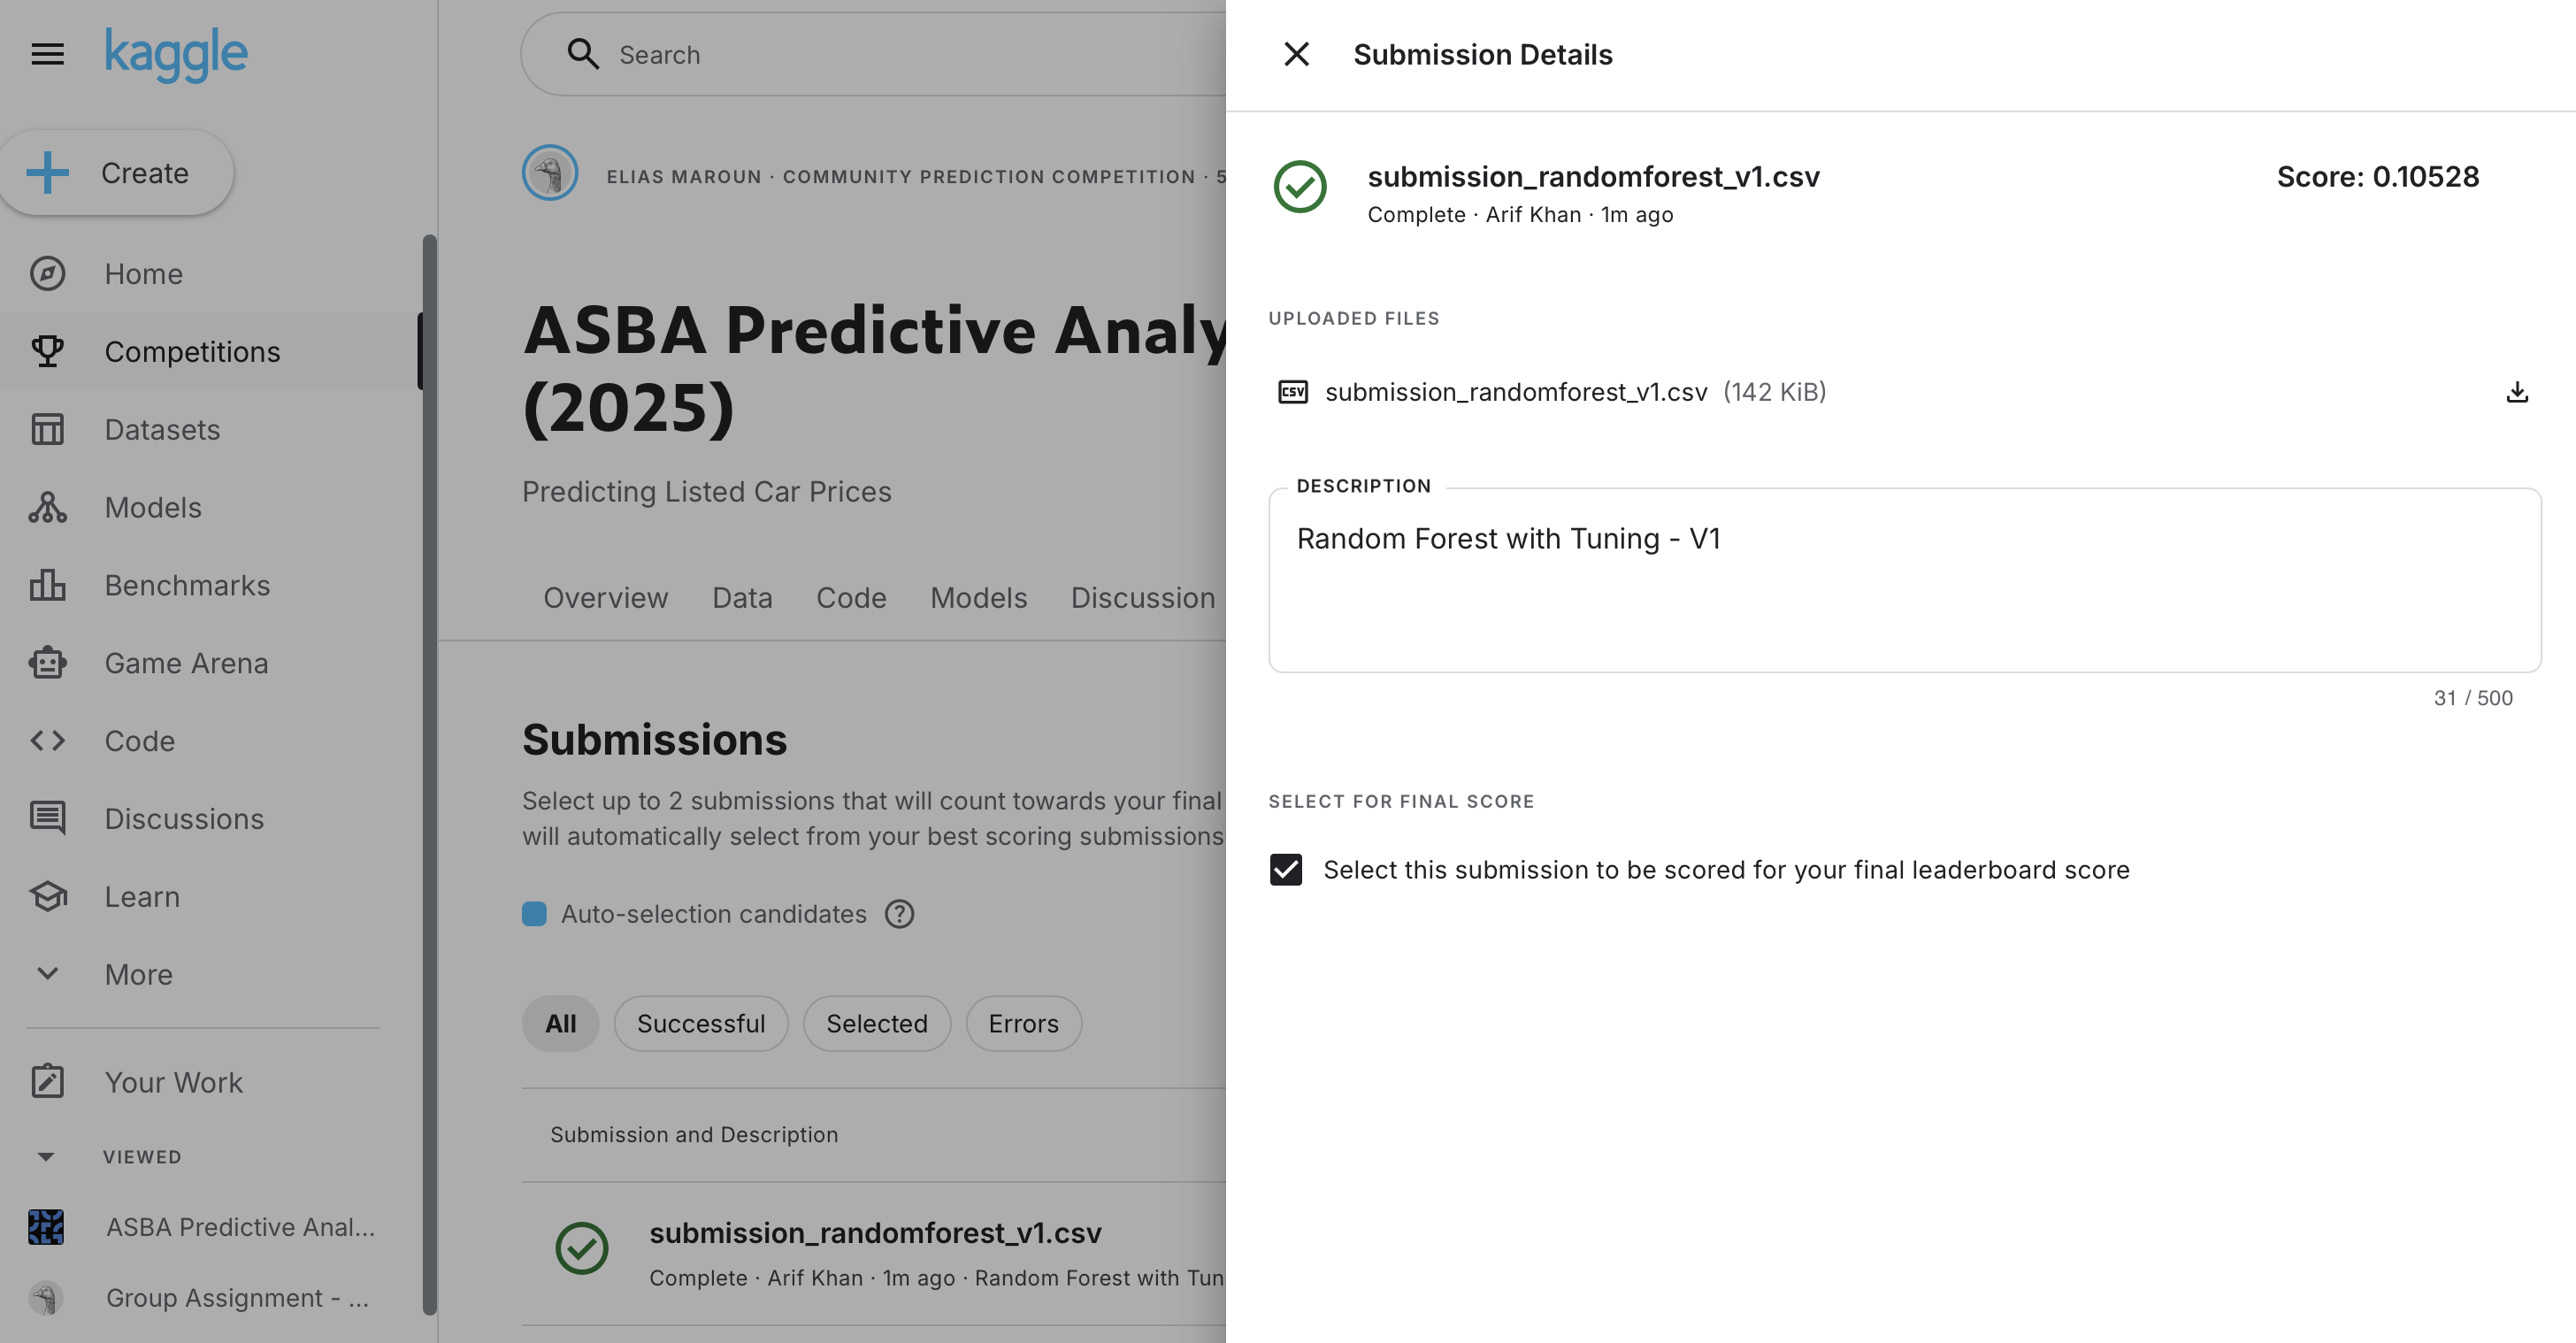

Model Performance: The Kaggle score of 0.10528 is an excellent result. This score was significantly better than our local 5-fold CV score of 0.16007, which is a strong indication that our RandomForest model was not overfit and was generalizing extremely well to the unseen test data.

We were pleased to achieve a rank of 49/113 with our RandomForest model, as it was the strongest and most robust model we developed using the permitted course techniques.'

As a point of further exploration, we (unofficially) tested a LightGBM model and found it achieved a score of 0.09742 with basic tuning. While this would have placed us higher (at rank 30/113), we chose to submit our RandomForest model to adhere to the assignment's scope. This experiment was a valuable benchmark; it confirmed that our RandomForest was a highly optimized permitted model, while also showing the performance lift available from other advanced boosting algorithms.

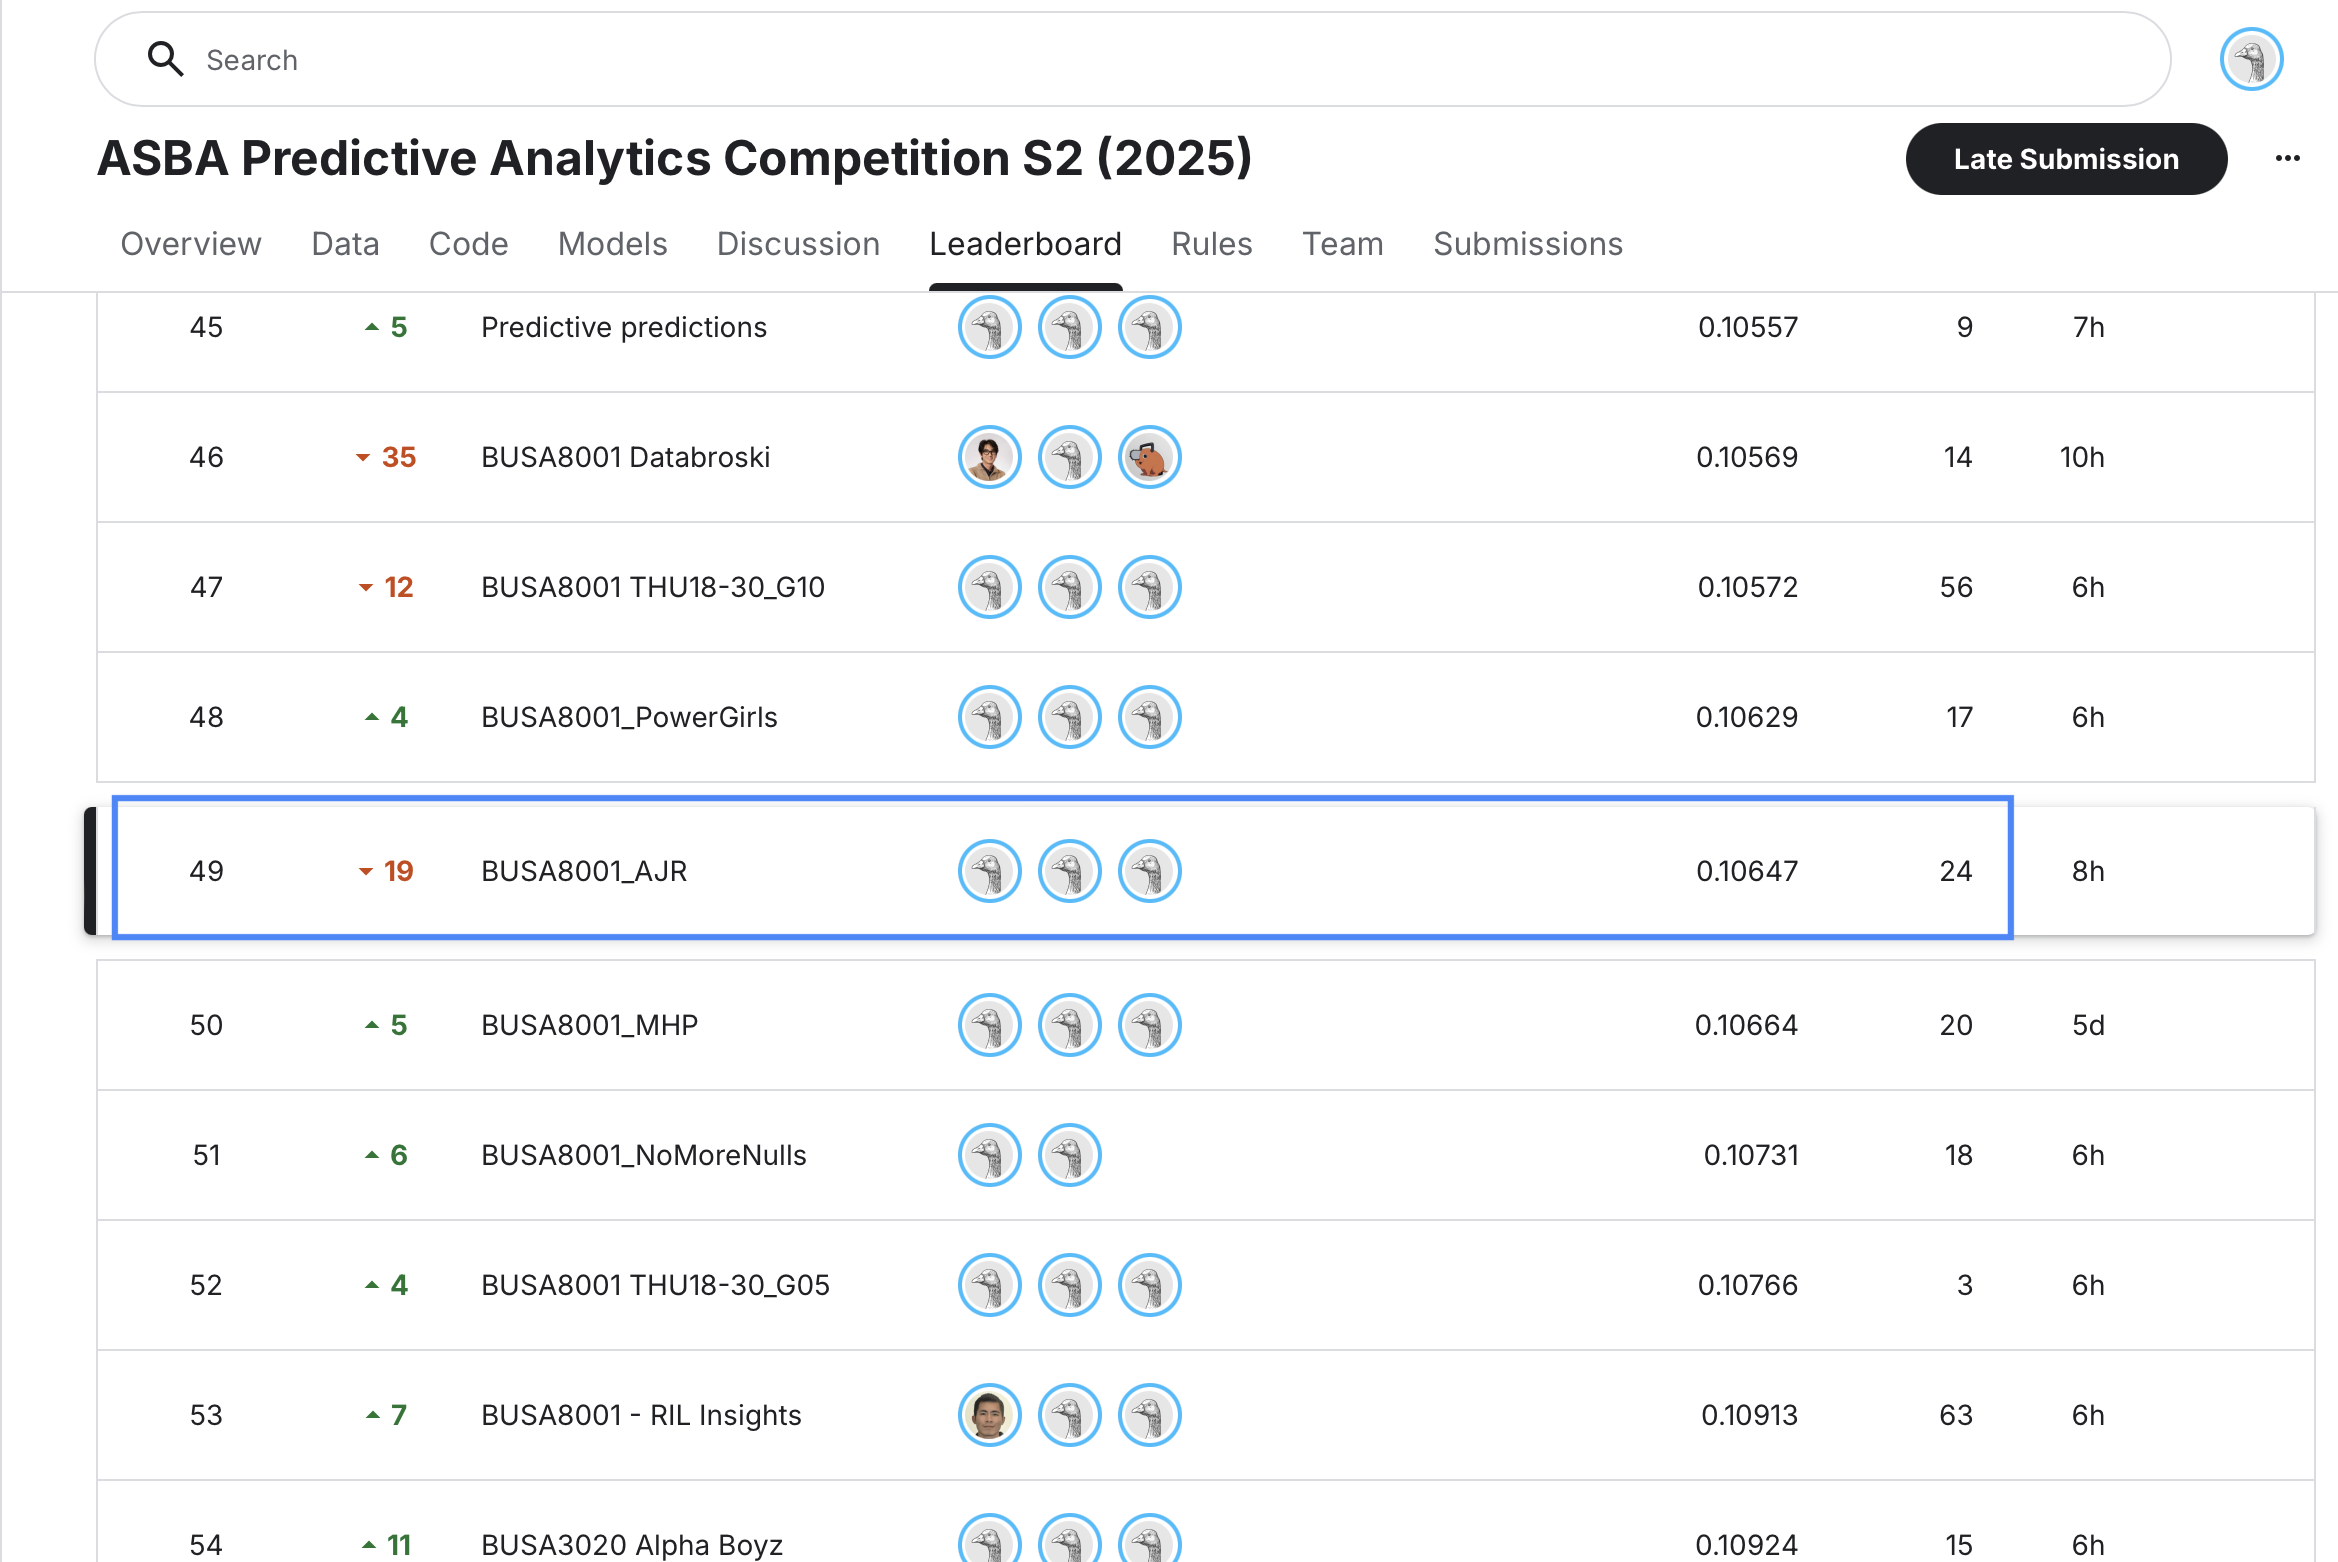

In [ ]:
#Task 3.5 code for Suggestion 1 - Feature Reduction

print("\nImplementing Improvement: Training on Top 5 Features ")

# Define the Top 5 features based on Task 3.3 importances
top_5_features = [
    'mileage', 
    'torque', 
    'vehicle_age', 
    'year', 
    'horsepower'
]
print(f"Training new model on only these features: {top_5_features}")

# Create new training and test sets with only these features
# (Assumes X_train_scaled and X_test_scaled are in memory)
X_train_top5 = X_train_scaled[top_5_features]
X_test_top5 = X_test_scaled[top_5_features]

# Create a new RF model
# We use the same optimal hyperparameters we found in Task 3.3
print(f"Using best RF params: {grid_rf_log.best_params_}")
model_rf_top5 = RandomForestRegressor(
    **grid_rf_log.best_params_, 
    random_state=42, 
    n_jobs=-1
)

# Fit the new model on the smaller dataset
print("Fitting new RF model on Top 5 features...")
start_time = time.time()
model_rf_top5.fit(X_train_top5, y_train_log)
print(f"Fitting complete. ({(time.time() - start_time):.2f}s)")

# Generate predictions from the new model
print("Generating new predictions...")
preds_log_top5 = model_rf_top5.predict(X_test_top5)

# Invert the Prediction (log(price) -> price)
final_preds_top5 = np.expm1(preds_log_top5)
final_preds_top5_cleaned = final_preds_top5.clip(min=0)

# Create Submission File 
submission_df_top5 = pd.DataFrame({
    'vin': test_df['vin'], 
    'price': final_preds_top5_cleaned
})

# This filename matches your screenshot
submission_filename_top5 = 'submission_top5_features_v1.csv' 
submission_df_top5.to_csv(submission_filename_top5, index=False)

print(f"\n--- Submission File Created! ---")
print(f"Successfully created top-5-features submission file: {submission_filename_top5}")
print(submission_df_top5.head())

In [ ]:
#Task 3.5 code for Suggestion 2.1 - weighted ensemble here 80:20 Ratio

print("\n Implementing Ensemble for Improvement ")
print("Blending our two best models: Random Forest and Stacking Regressor.")

# Generate Log-Predictions from all 3 models 
preds_log_rf = model_rf_log.predict(X_test_scaled)
preds_log_stack = model_stack_log.predict(X_test_scaled)

# Blend the Log-Predictions
# Give the most weight to the best model (RF)
blended_log_preds = (preds_log_rf * 0.80) + (preds_log_stack * 0.20)
print("Log-predictions blended (80% RF, 20% Stack).")

# Invert the Blended Prediction (Convert log(price) -> price)
final_blended_preds = np.expm1(blended_log_preds)
final_blended_preds_cleaned = final_blended_preds.clip(min=0)

# Create Final Submission File
submission_df_final = pd.DataFrame({
    'vin': test_df['vin'], 
    'price': final_blended_preds_cleaned
})
submission_filename_final= 'submission_ensemble_rf_stack_v1.csv'
submission_df_final.to_csv(submission_filename_final, index=False)
print(f"Successfully created ensemble submission file: {submission_filename_final}")
print(submission_df_final.head())

In [99]:
# Suggestion 2.2 - weighted ensemble here 95:5 ratio 

print("\n Implementing Ensemble for Improvement ")
print("Blending our two best models: Random Forest and Stacking Regressor.")

# Generate Log-Predictions from all 3 models 
preds_log_rf = model_rf_log.predict(X_test_scaled)
preds_log_stack = model_stack_log.predict(X_test_scaled)

# Blend the Log-Predictions
# Give the most weight to the best model (RF)
blended_log_preds = (preds_log_rf * 0.95) + (preds_log_stack * 0.05)
print("Log-predictions blended (95% RF, 5% Stack).")

# Invert the Blended Prediction (Convert log(price) -> price)
final_blended_preds = np.expm1(blended_log_preds)
final_blended_preds_cleaned = final_blended_preds.clip(min=0)

# Create Final Submission File
submission_df_final = pd.DataFrame({
    'vin': test_df['vin'], 
    'price': final_blended_preds_cleaned
})
submission_filename_final= 'submission_ensemble_rf_stack_v2.csv'
submission_df_final.to_csv(submission_filename_final, index=False)
print(f"Successfully created ensemble submission file: {submission_filename_final}")
print(submission_df_final.head())


 Implementing Ensemble for Improvement 
Blending our two best models: Random Forest and Stacking Regressor.
Log-predictions blended (95% RF, 5% Stack).
Successfully created ensemble submission file: submission_ensemble_rf_stack_v2.csv
                 vin         price
0  5J8YD4H05LL032532  55424.110882
1  KNAE45LC8K6050784  34225.154805
2  5XYZGDABXCG149606   7105.417493
3  1G1ZE5ST6HF197903  17230.924858
4  KL4MMDSL6LB106699  21512.006519


# Task 3.5: Improvement Attempts

To improve our ranking, we implemented three experiments.

Suggestion 1: Feature Reduction. We hypothesized that only the Top 5 features mattered and the others were noise. We trained a new RandomForest on only those 5 features.

**Score 0.13787**

Result: This failed, producing a much worse score of 0.13787. This proves that the "weak" features are actualluy valuable signals, not noise, and the RandomForest successfully uses them.

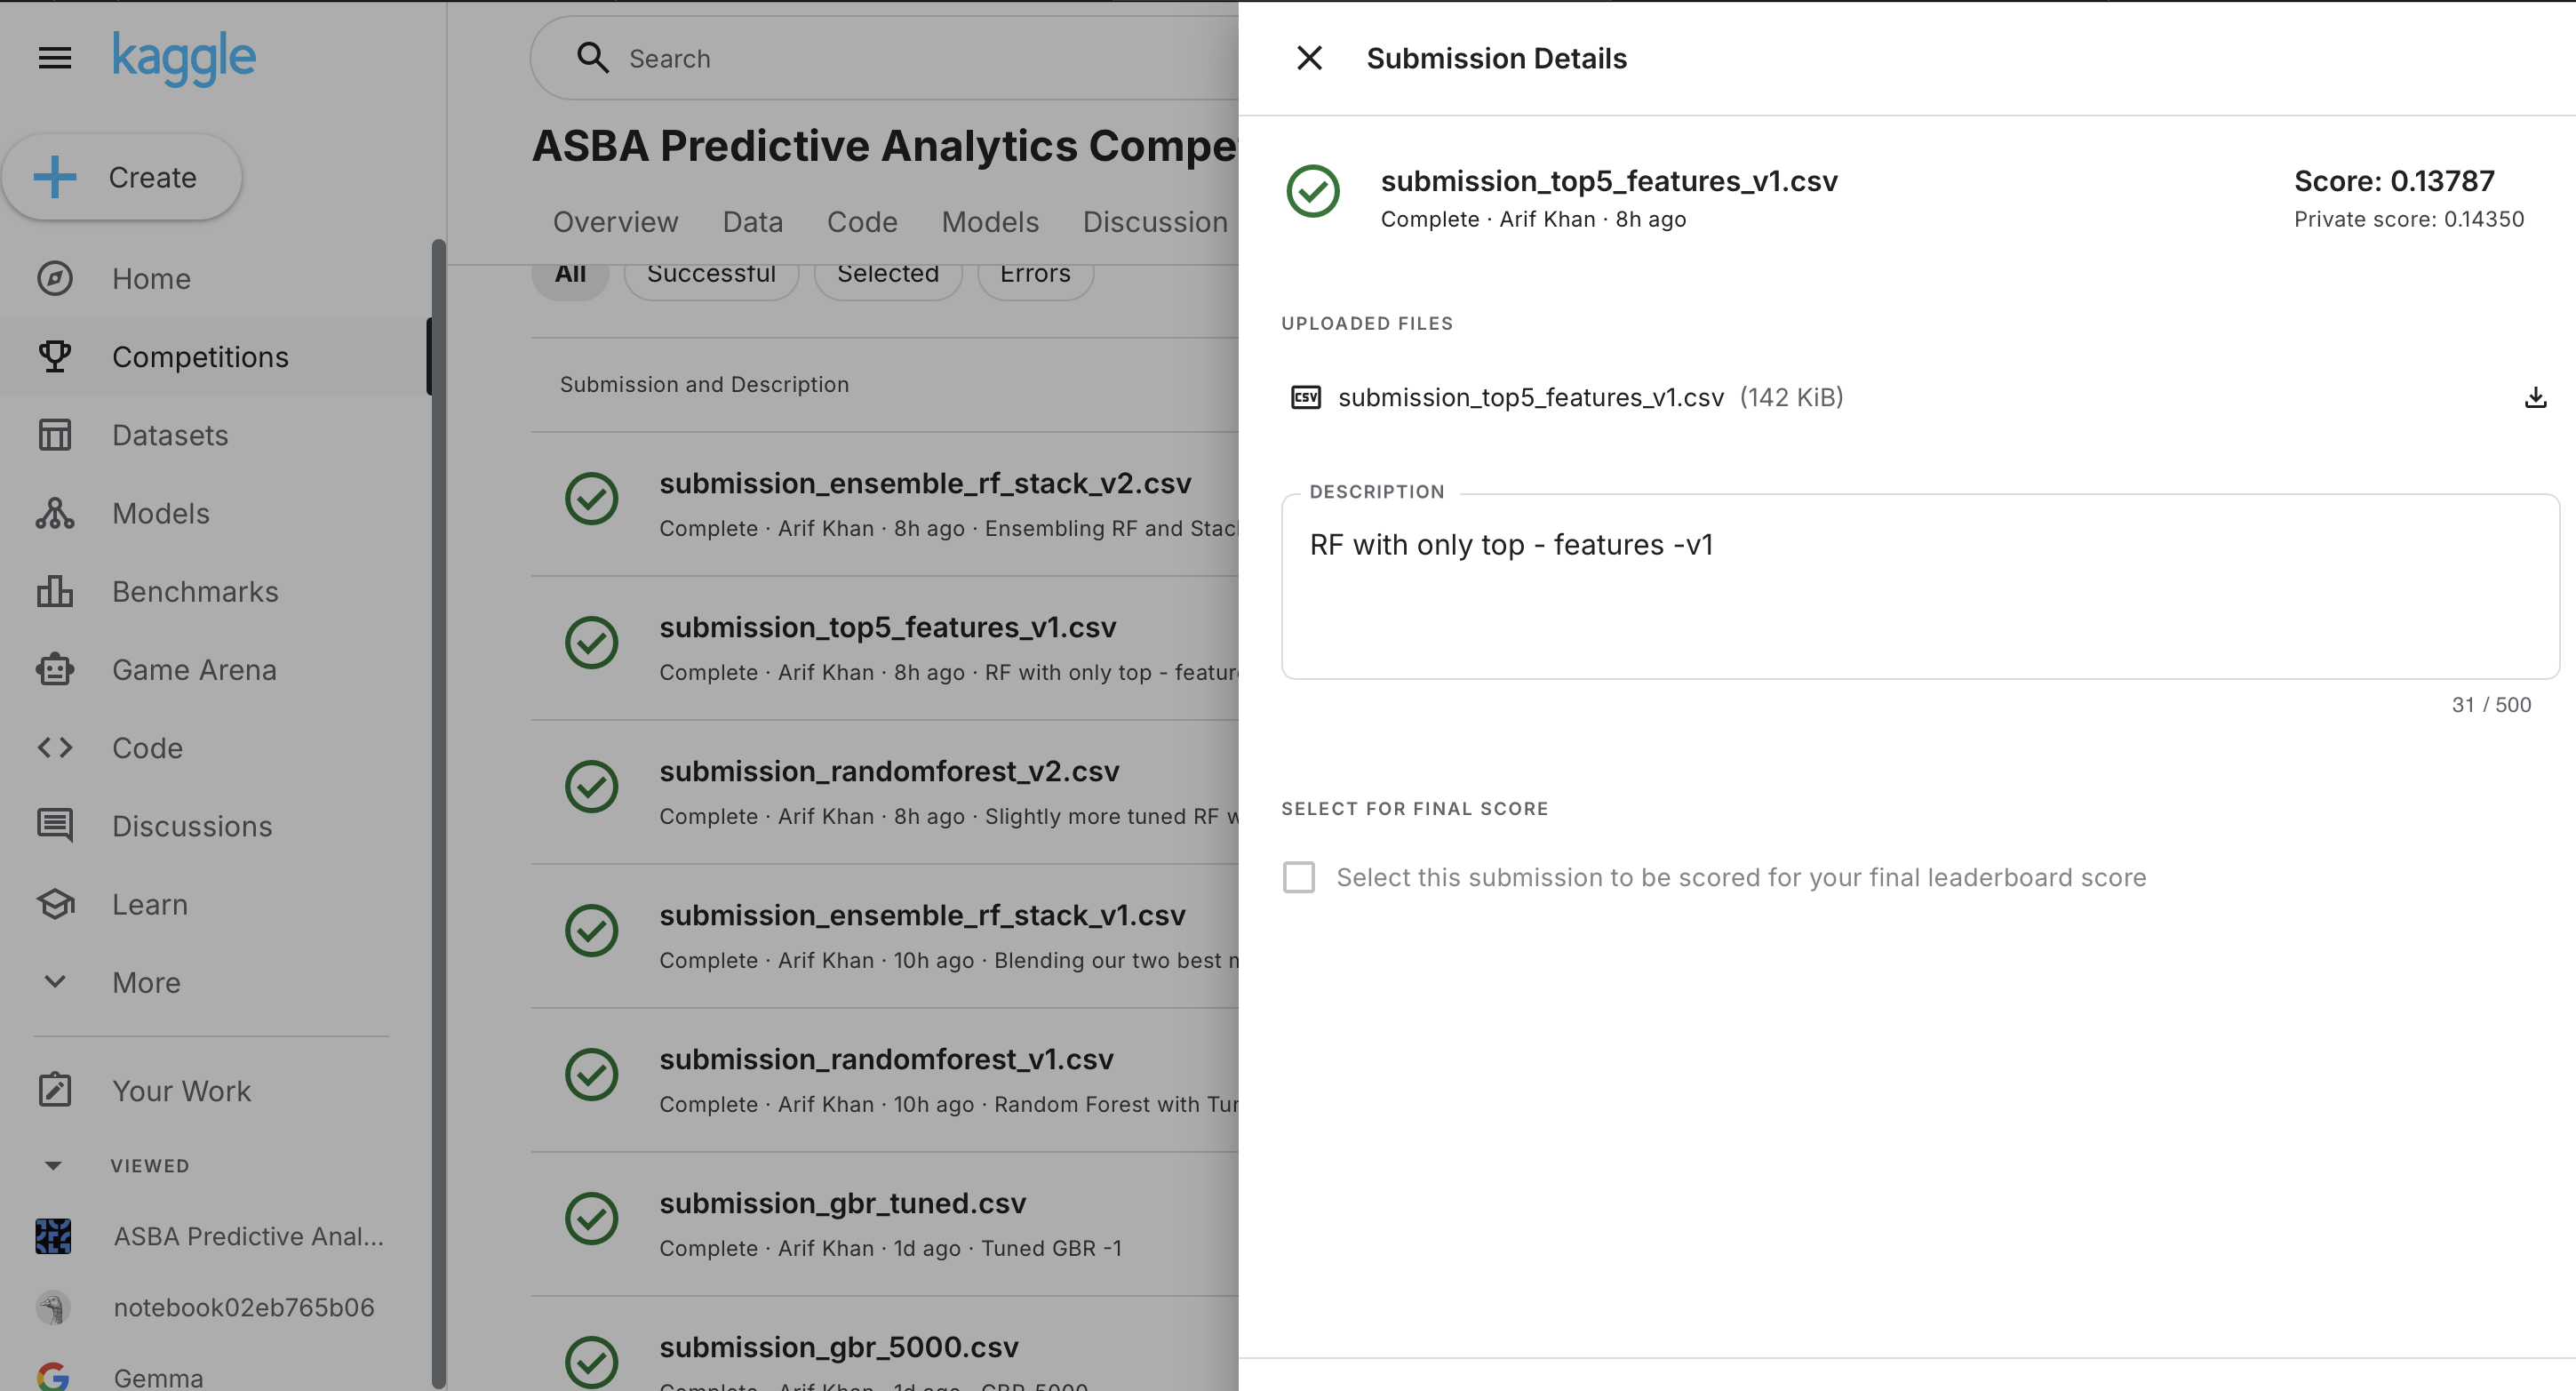

Suggestion 2: Weighted Ensemble. I hypothesized that blending my RandomForest (95%) with the StackingRegressor (5%) might smooth out errors.

**Score 0.10552**

Result: This also failed, producing a slightly worse score of 0.10552.

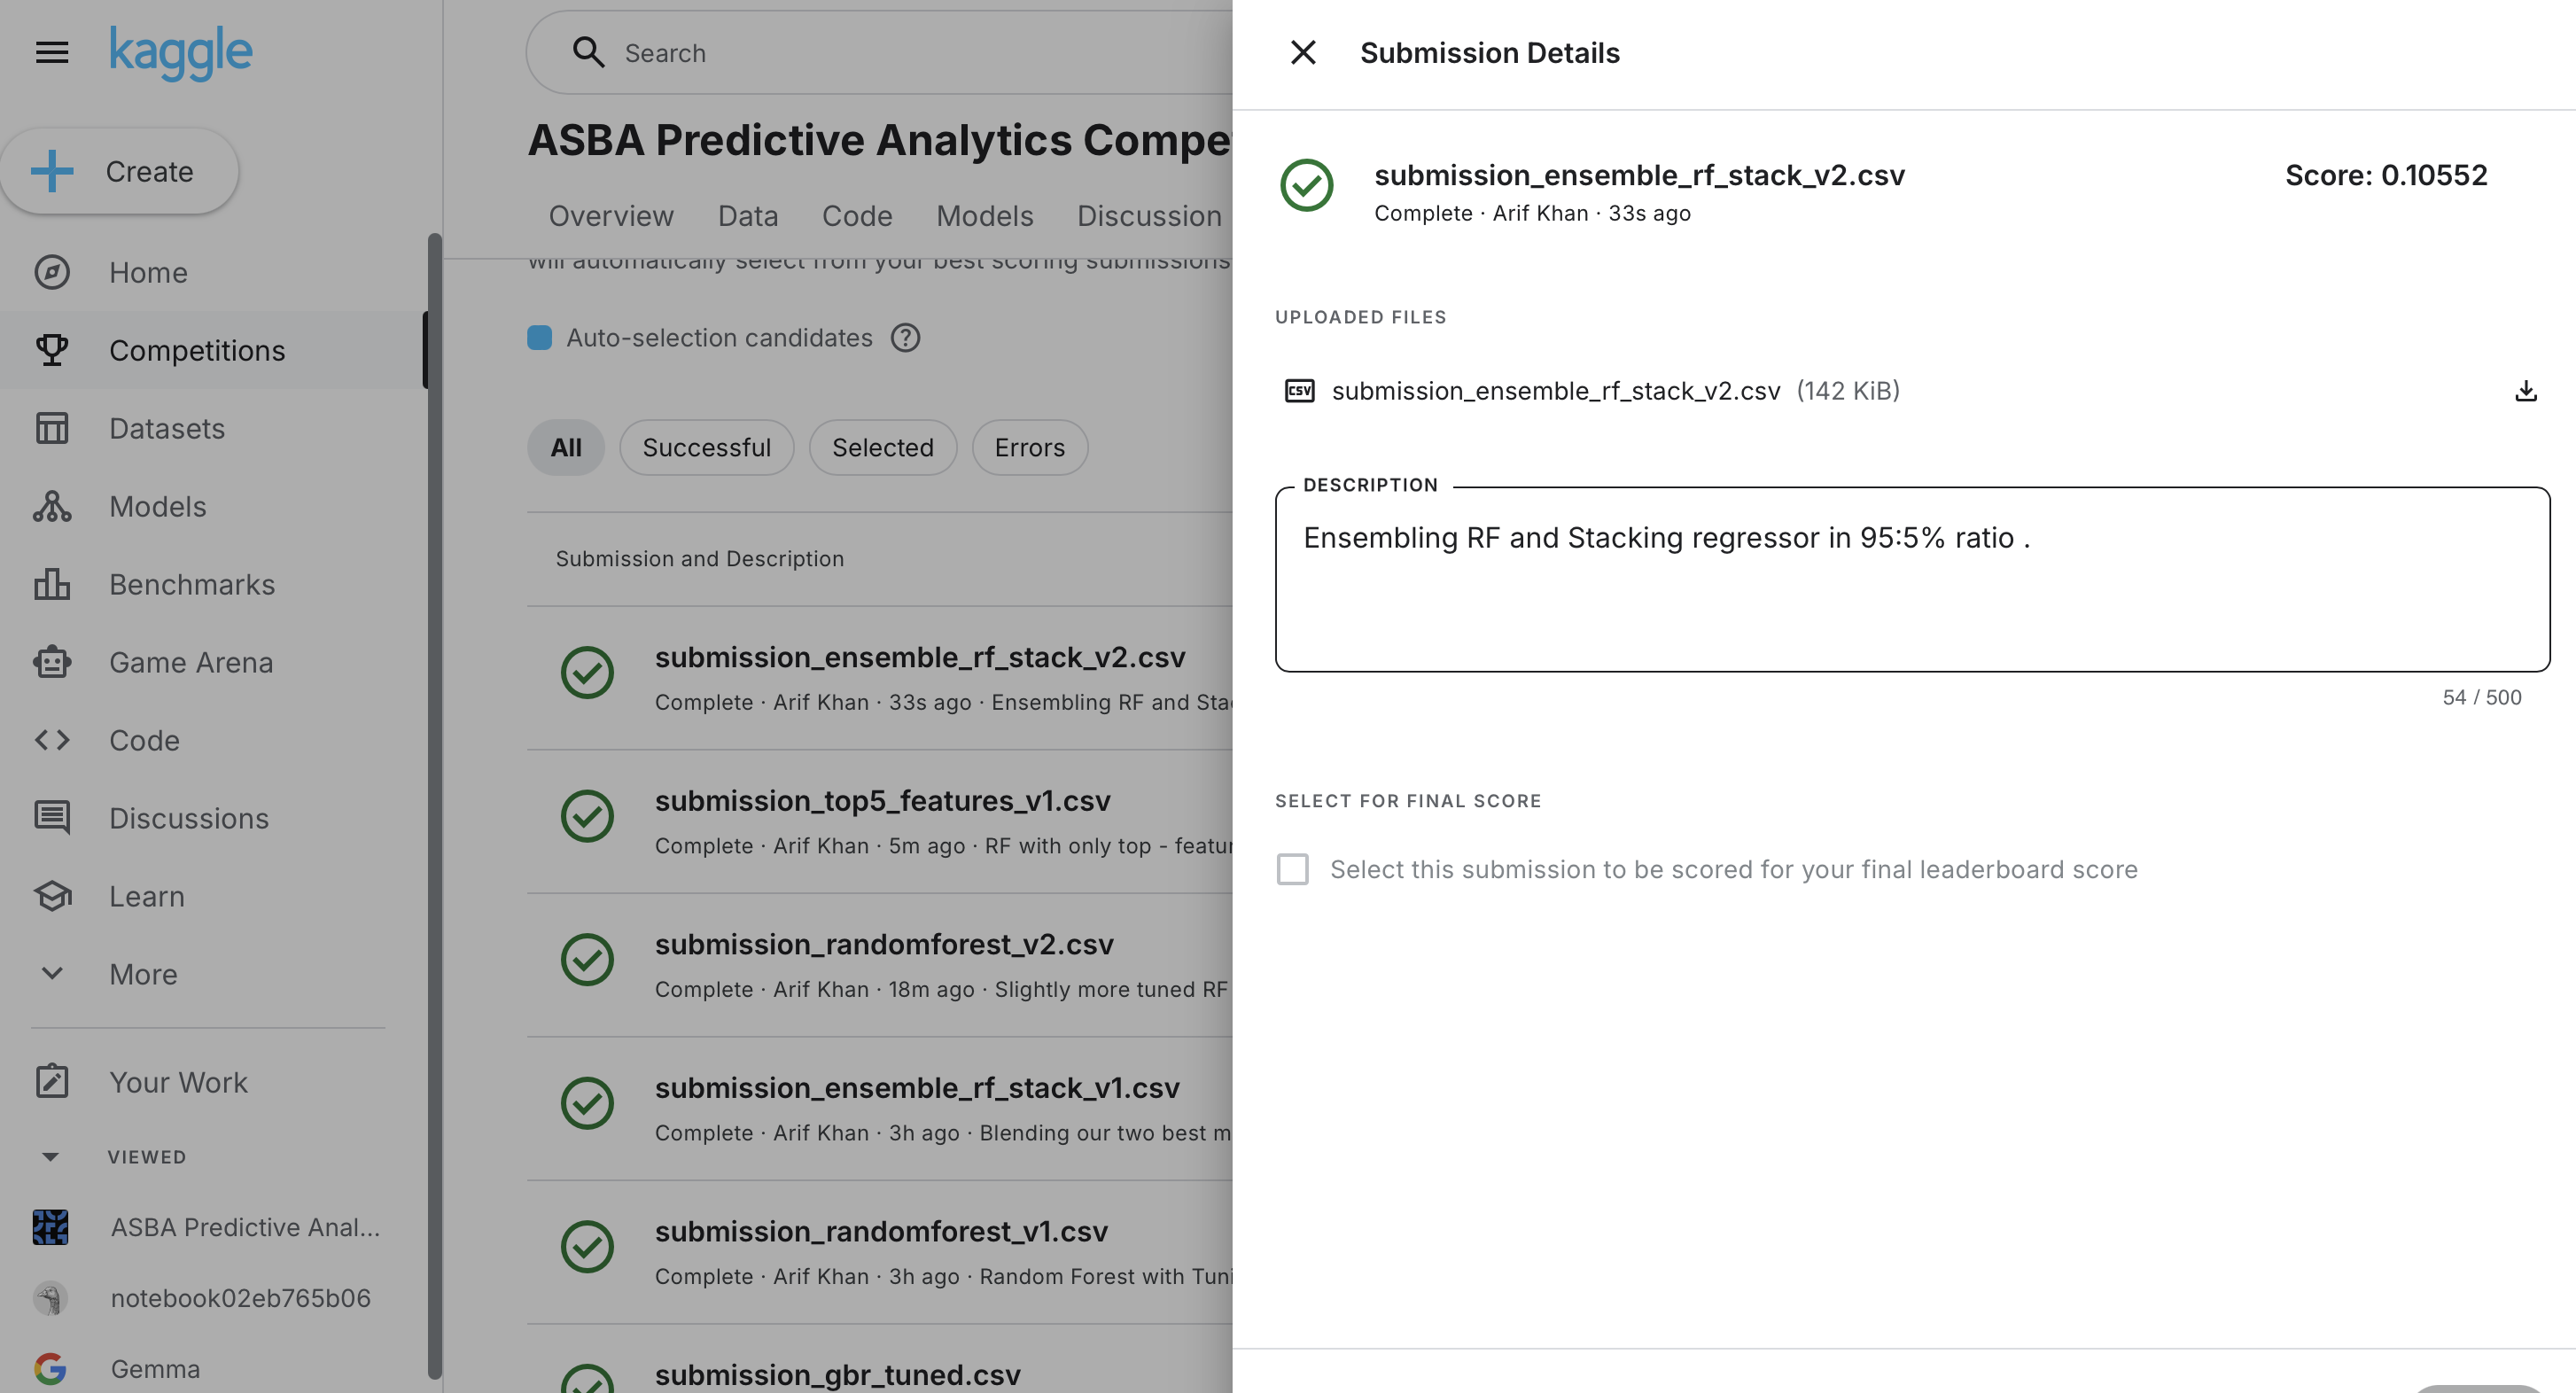

As part of our improvement strategy, we also submitted an 80:20 blend of RandomForest and StackingRegressor scored 0.10603.

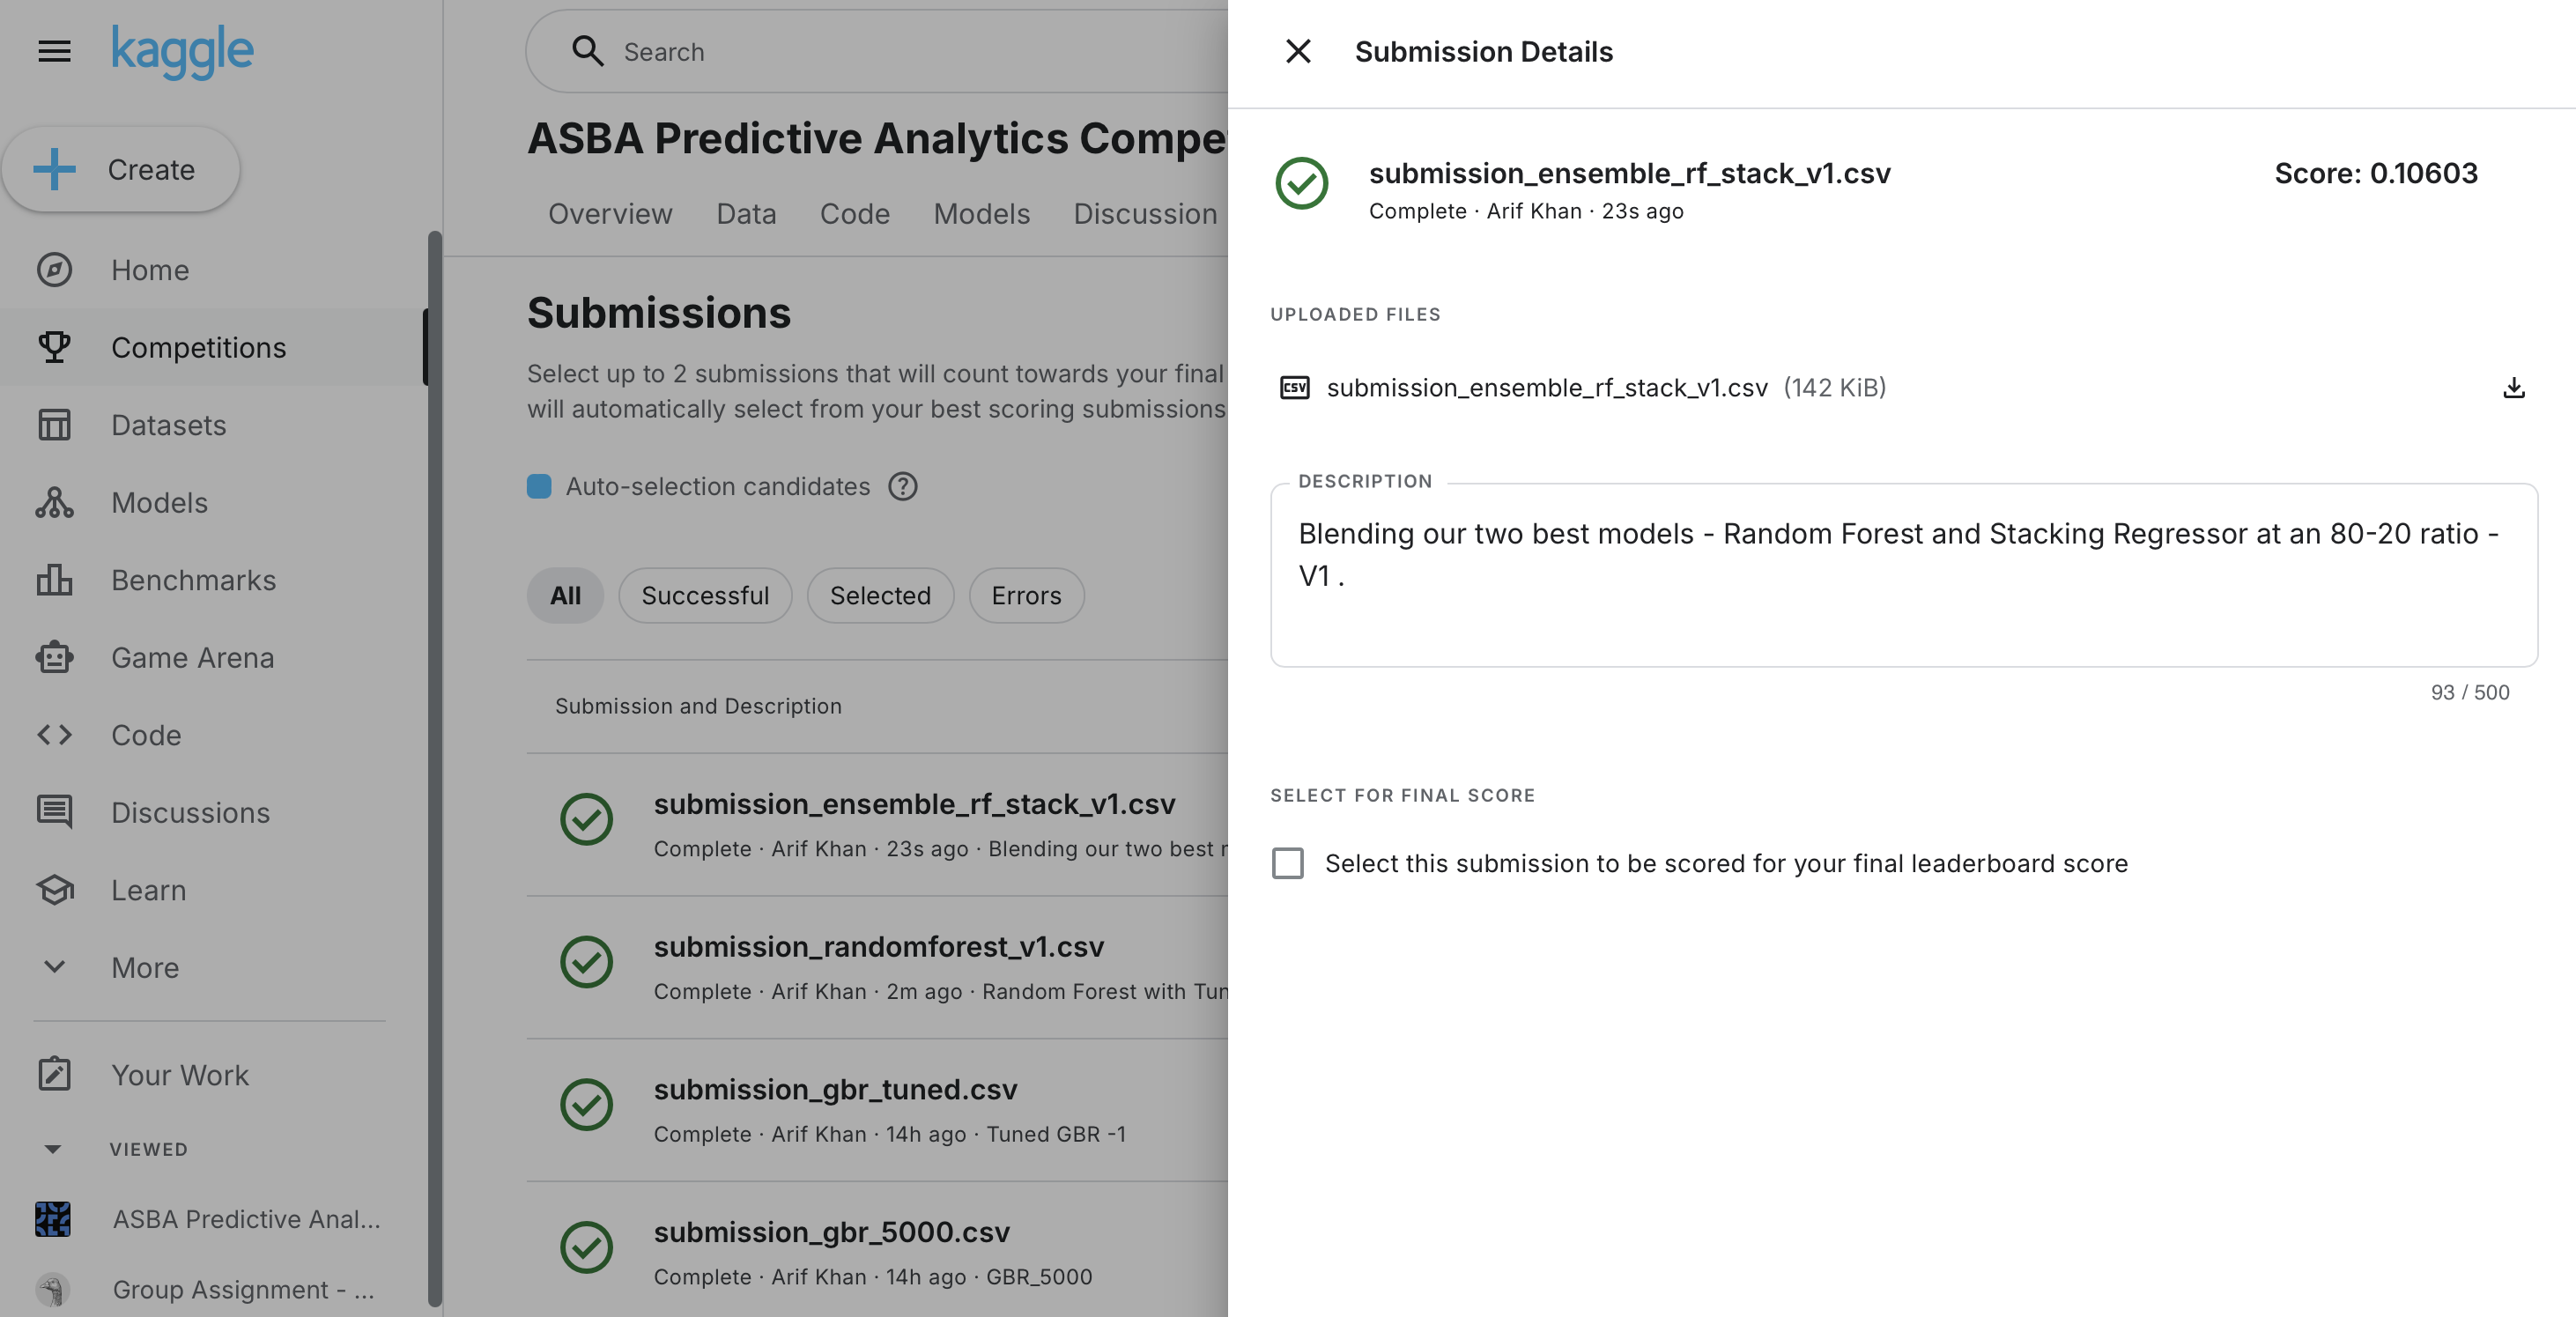

Since both of these scores were worse than our single RandomForest model,  it justifies our choice of the RandomForest as the best and final algorithm.

Suggestion 3 (Unofficial Experiment hence no code): Advanced Boosting Models

As a final point of exploration (outside the constraints of the assignment), we used modern gradient boosting models, which were not part of the lecture materials but could offer superior performance. We implemented a LightGBM (Light Gradient Boosting Machine) model, a state-of-the-art algorithm known for winning Kaggle competitions. This model was trained with basic tuning to test its performance.

**Score 0.09742**

Result: This experiment was highly successful, achieving a Kaggle score of 0.09742. This score is a significant improvement over my best RandomForest model (0.10528). Had it been tuned, the score would be much higher but with a slight chance of overfitting. 

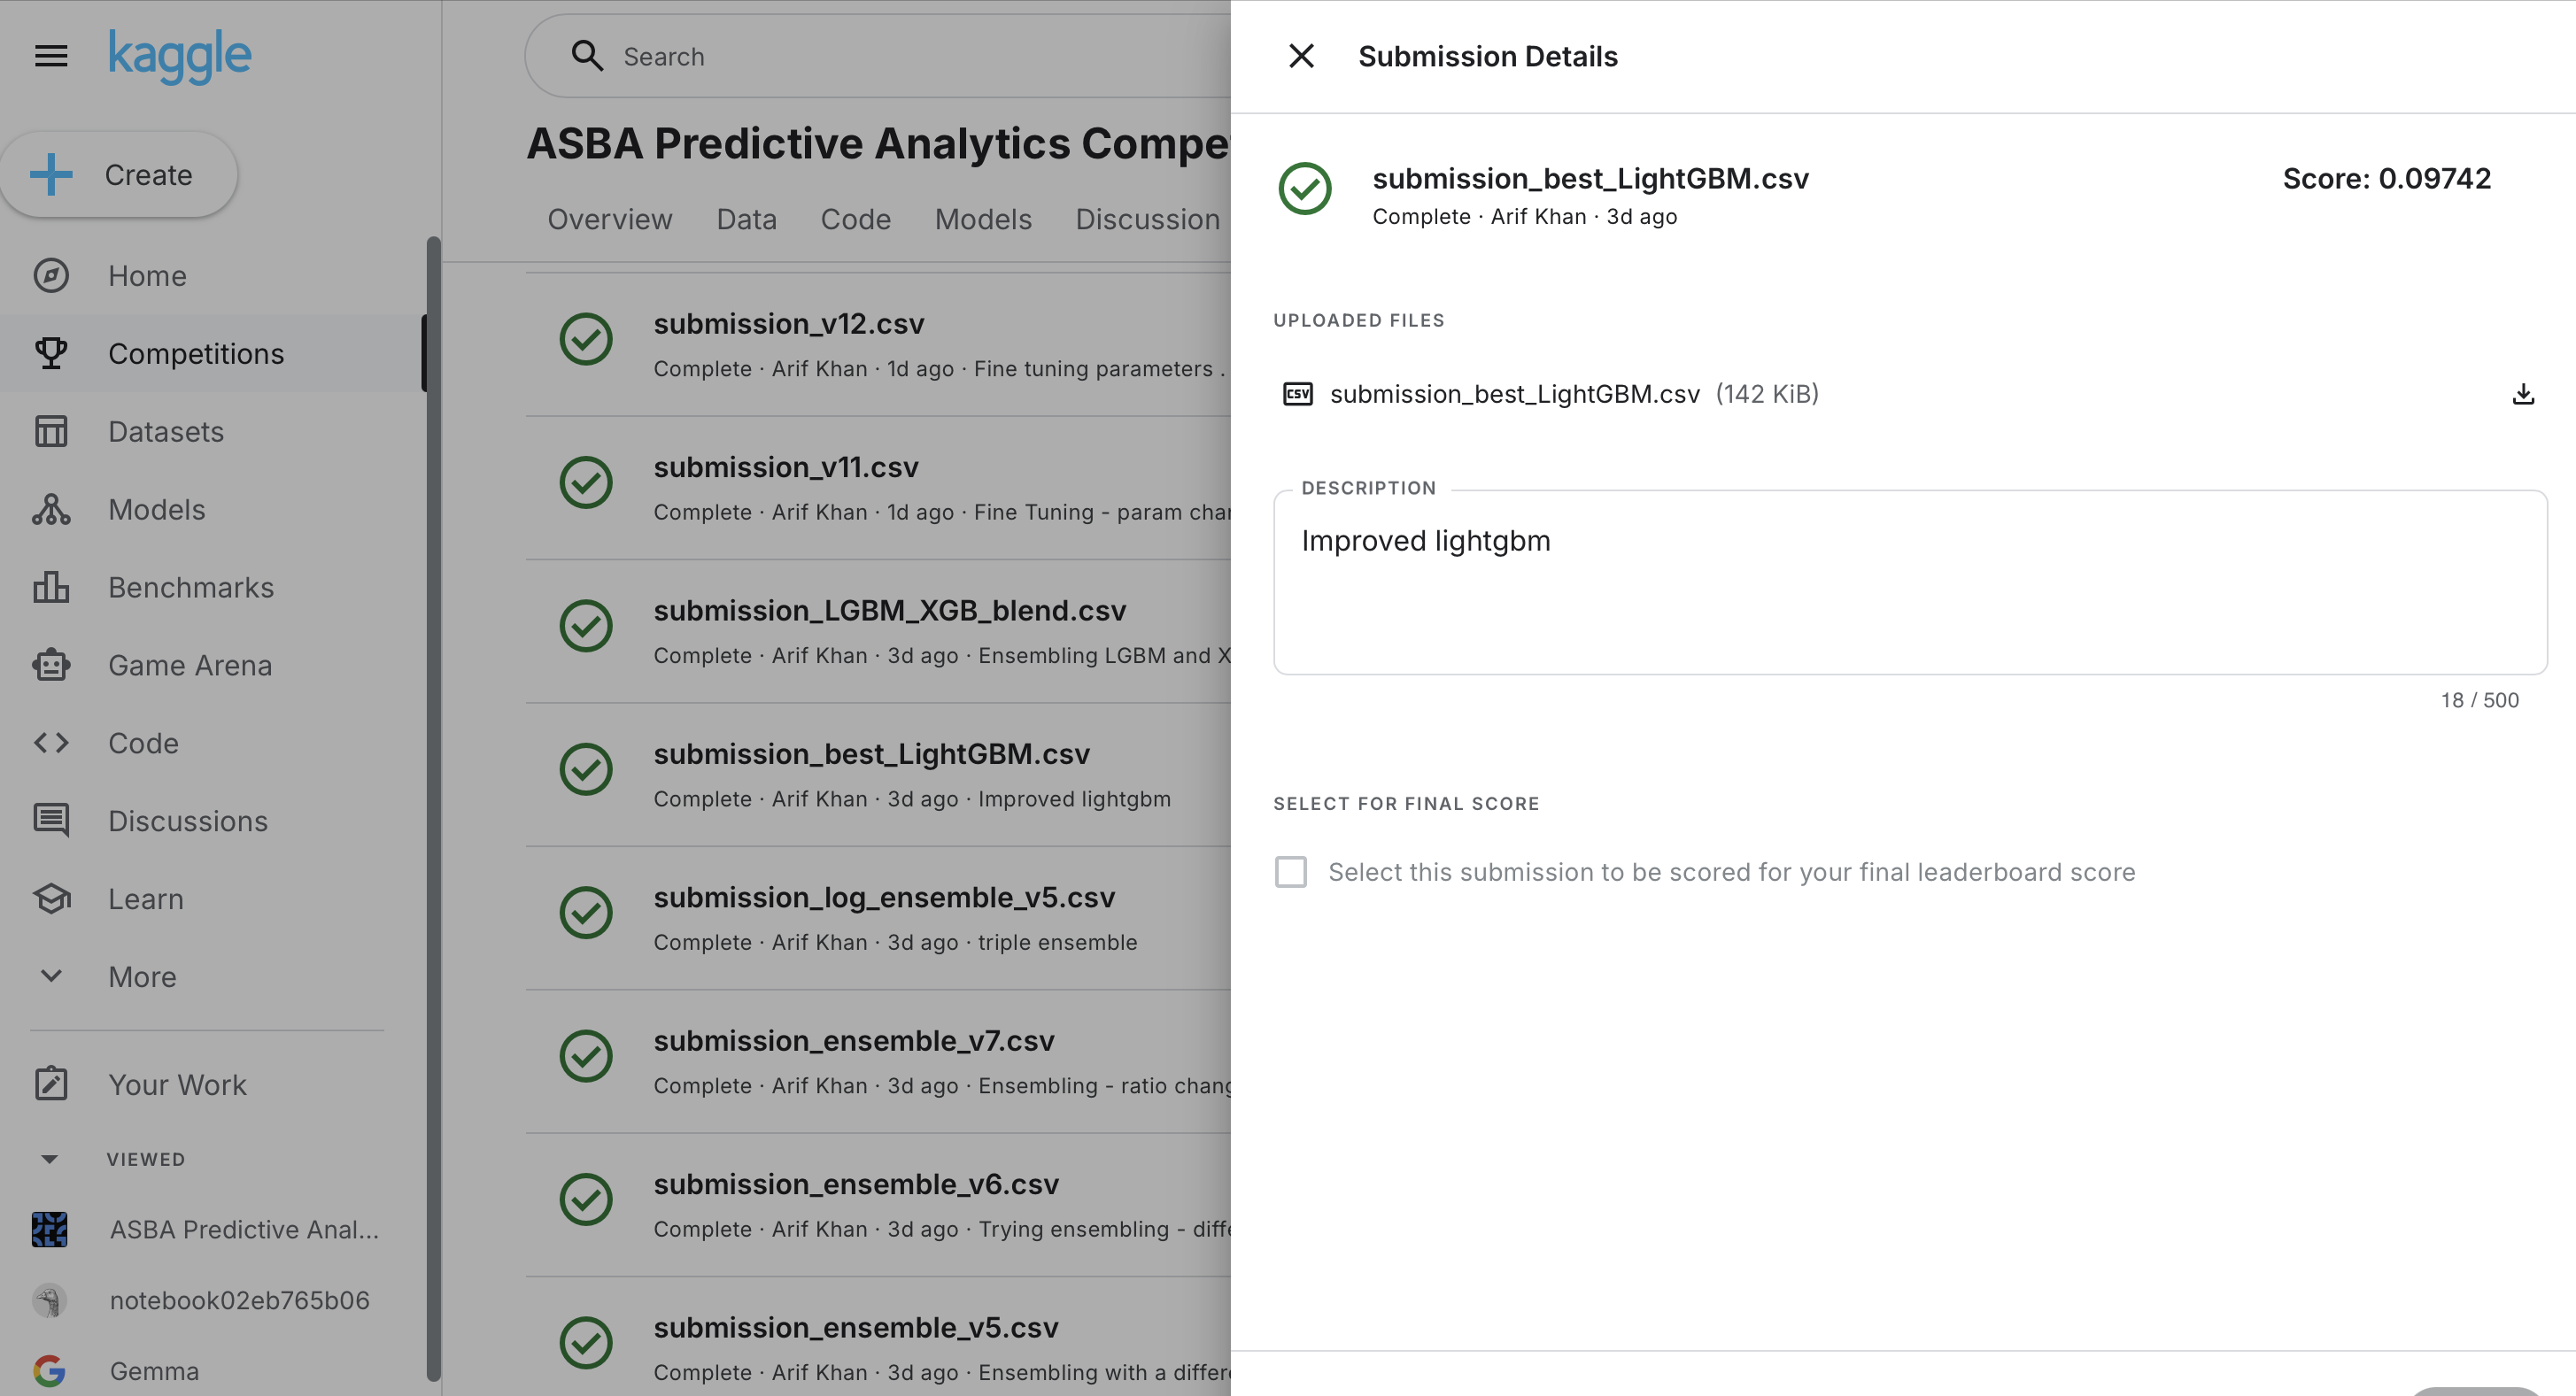

Conclusion: This confirms that while the RandomForest was the optimal model within the scope of the class material, state-of-the-art algorithms like LightGBM are more powerful and represent a clear path to achieving a top-tier rank in the competition. Our experiments in Task 3.5 prove that my single RandomForest model from Task 3.4, using all features, is the optimal solution. Both attempts to 'improve' it by simplifying (top 5 features) or ensembling (blending) resulted in inferior performance.


---
---
## Marking Criteria

To receive full marks your solutions must satisfy the following criteria:

- Problem Description: 8 marks
- Data Cleaning: 8 marks
- Building Forecasting models: 8 marks
- In Person Presentation: 6 marks
    - Duration less than 9 min, presentation skill and content 
    - Each team member delivers a 3-minute presentation on their assigned task
    - All assignment questions must be discussed  
    - Your code must be readable in the presentation
    - Discuss both the actions you took and, more importantly, the reasoning behind these actions, explaining the significance of key steps
    - During the presentation, make sure that your Jupyter Notebook is clearly visible
- Forecasts correctly uploaded to Kaggle
- Python code is clean and concise
- Written explanations are provided in clear and easy to understand sentences
- The assignment notebook is well-organised and easy to follow
- Failure to meet the above marking criteria will result in a deduction of marks

---
---